In [8]:
import pythia8
import fastjet
import numpy as np
import awkward as ak
import vector
import matplotlib.pyplot as plt
import random
import pickle
from pathlib import Path
import gzip
from typing import List, Tuple, Dict, Union, Sequence, Any
import clust_gen

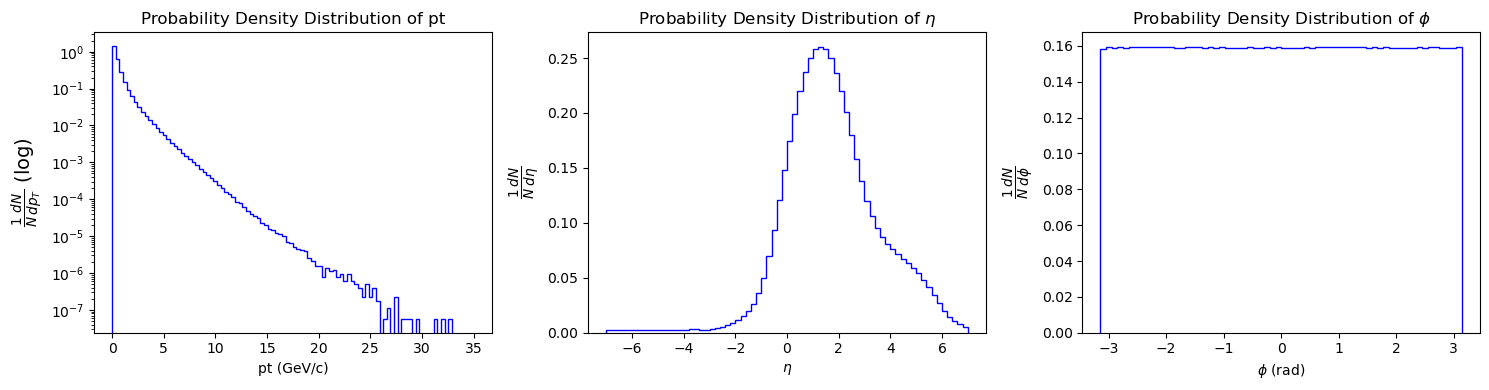

In [9]:
# ---- settings ----
data_dir = Path("/home/ajperillo19/anaconda3/envs/EIC_ENV")
n_batches = 40
files = [data_dir / f"batch_{i:02d}.pkl.gz" for i in range(n_batches)]

# choose bin edges
bins_pt  = np.linspace(0.0, 35.0, 101)      # example: 0-50 GeV in 100 bins
bins_eta = np.linspace(-7.0, 7.0, 71)       # example coverage
bins_phi = np.linspace(-np.pi, np.pi, 65)   # 64 bins across [-pi,pi]

counts_pt  = np.zeros(len(bins_pt)-1, dtype=np.int64)
counts_eta = np.zeros(len(bins_eta)-1, dtype=np.int64)
counts_phi = np.zeros(len(bins_phi)-1, dtype=np.int64)
total_particles = 0

def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

# ---- accumulate counts per batch ----
for fn in files:
    if not fn.exists():
        print("Missing:", fn); 
        continue
    with open(fn, "rb") as f:
        ak_particle_list = pickle.load(f)

    # convert to awkward and flatten
    ak_arr = ak.Array(ak_particle_list)
    allp = ak.flatten(ak_arr)
    if len(allp) == 0:
        continue

    pt_vals  = ak.to_numpy(allp["pt"])
    eta_vals = ak.to_numpy(allp["eta"])
    phi_vals = wrap_phi(ak.to_numpy(allp["phi"]))

    # mask finite
    mpt  = np.isfinite(pt_vals)
    meta = np.isfinite(eta_vals)
    mphi = np.isfinite(phi_vals)

    c_pt,  _ = np.histogram(pt_vals[mpt],  bins=bins_pt)
    c_eta, _ = np.histogram(eta_vals[meta], bins=bins_eta)
    c_phi, _ = np.histogram(phi_vals[mphi], bins=bins_phi)

    counts_pt  += c_pt
    counts_eta += c_eta
    counts_phi += c_phi
    total_particles += int(np.sum(mpt))   # use pt count representative

# ---- convert to probability density: density = counts / (N * bin_width) ----
N = float(total_particles)
binw_pt  = (bins_pt[1:] - bins_pt[:-1])
binw_eta = (bins_eta[1:] - bins_eta[:-1])
binw_phi = (bins_phi[1:] - bins_phi[:-1])

# avoid division by zero (shouldn't happen if bins have non-zero width)
density_pt  = counts_pt  / (N * binw_pt)
density_eta = counts_eta / (N * binw_eta)
density_phi = counts_phi / (N * binw_phi)

# ---- prepare plotting using plt.hist (centers as x, density as weights) ----
centers_pt  = 0.5 * (bins_pt[:-1] + bins_pt[1:])
centers_eta = 0.5 * (bins_eta[:-1] + bins_eta[1:])
centers_phi = 0.5 * (bins_phi[:-1] + bins_phi[1:])

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# PT: log y-scale. Can't plot log of zeros -> add tiny eps or mask zeros
eps = 1e-30
# Use plt.hist with centers and density as weights: heights will equal density_i
axes[0].hist(centers_pt, bins=bins_pt, weights=density_pt, histtype='step', alpha=1, edgecolor='blue')
axes[0].set_yscale('log')
axes[0].set_title('Probability Density Distribution of pt')
axes[0].set_xlabel('pt (GeV/c)')
axes[0].set_ylabel(r'$\frac{1}{N}\frac{dN}{dp_T}$ (log)', fontsize = 14)

# ETA
axes[1].hist(centers_eta, bins=bins_eta, weights=density_eta, histtype='step', alpha=1, edgecolor='blue')
axes[1].set_xlabel(r'$\eta$')
axes[1].set_title(fr'Probability Density Distribution of $\eta$')
axes[1].set_ylabel(r'$\frac{1}{N}\frac{dN}{d\eta}$', fontsize = 14)

# PHI (wrapped to [-pi,pi])
axes[2].hist(centers_phi, bins=bins_phi, weights=density_phi, histtype='step', alpha=1, edgecolor='blue')
axes[2].set_xlabel(r'$\phi$ (rad)')
axes[2].set_title(fr'Probability Density Distribution of $\phi$')
axes[2].set_ylabel(r'$\frac{1}{N}\frac{dN}{d\phi}$', fontsize  = 14)

plt.tight_layout()
plt.savefig("Char_part_distro.png")
plt.show()

In [11]:
QUARK_PDG_SET = {1,2,3,4,5,6} # quark/anti-quark PDG identifiers
GLUON_PDG = 21 # Gluon PDG identifier

def classify_cmother(
    cmother: List[List[List[int]]],
    min_fraction: float = 0.5
) -> Dict[str, object]:
    """
    Classify each jet by majority mother ID.

    Parameters
    ----------
    cmother : list of events; each event is a list of jet constituents; each jet is a list of integer PDG IDs
    min_fraction : float
        Minimum fraction required for a strict majority. Default 0.5 => requires strictly more than 50% of the mothers to be quarks or gluons in order to be considered quark or gluon jets.

    Returns
    -------
    dict with keys:
      - 'quark_indices' : list of (event_idx, jet_idx) 
      - 'gluon_indices' : list of (event_idx, jet_idx) 
      - 'ambiguous_indices' : list of (event_idx, jet_idx) (ties or no majority)
      - 'empty_indices' : jets with no valid mother entries
      - 'summary' : list of dicts for each jet with counts and classification
    """
    quark_indices = []
    gluon_indices = []
    ambiguous_indices = []
    empty_indices = []
    summary = []

    for ei, event in enumerate(cmother):
        # event is a list of jet constituents
        for ji, jet_mothers in enumerate(event):
            # iterate through
            jet_mothers_py = ak.to_list(jet_mothers)
            if len(jet_mothers_py) == 0 :
                empty_indices.append((ei, ji))
                summary.append({"event": ei, "jet": ji, "q":0, "g":0, "num_moth":0, "class":"empty"})
                continue

            qcnt = 0
            gcnt = 0
            num_moth = 0

            for m in jet_mothers:
                if m is None:
                    continue
                
                m_id = abs(m)

                num_moth += 1
                if m_id == GLUON_PDG:
                    gcnt += 1
                elif m_id in QUARK_PDG_SET:
                    qcnt += 1
                else:
                    # other mothers (Z, W, photons, etc.) are ignored for q/g counting
                    pass

            if num_moth == 0:
                empty_indices.append((ei, ji))
                summary.append({"event": ei, "jet": ji, "q":0, "g":0, "num_moth":0, "class":"empty"})
                continue

            qfrac = qcnt / num_moth
            gfrac = gcnt / num_moth

            if qfrac > min_fraction and qcnt > gcnt:
                quark_indices.append((ei, ji))
                classification = "quark"
            elif gfrac > min_fraction and gcnt > qcnt:
                gluon_indices.append((ei, ji))
                classification = "gluon"
            else:
                ambiguous_indices.append((ei, ji))
                classification = "ambiguous"

            summary.append({
                "event": ei, "jet": ji, "q": qcnt, "g": gcnt, "num_moth": num_moth,
                "q_frac": qfrac, "g_frac": gfrac, "class": classification
            })

    return {
        "quark_indices": quark_indices,
        "gluon_indices": gluon_indices,
        "ambiguous_indices": ambiguous_indices,
        "empty_indices": empty_indices,
        "summary": summary
    }

Processing clustered_00.pkl
Processing clustered_01.pkl
Processing clustered_02.pkl
Processing clustered_03.pkl
Processing clustered_04.pkl
Processing clustered_05.pkl
Processing clustered_06.pkl
Processing clustered_07.pkl
Processing clustered_08.pkl
Processing clustered_09.pkl
Processing clustered_10.pkl
Processing clustered_11.pkl
Processing clustered_12.pkl
Processing clustered_13.pkl
Processing clustered_14.pkl
Processing clustered_15.pkl
Processing clustered_16.pkl
Processing clustered_17.pkl
Processing clustered_18.pkl
Processing clustered_19.pkl
Processing clustered_20.pkl
Processing clustered_21.pkl
Processing clustered_22.pkl
Processing clustered_23.pkl
Processing clustered_24.pkl
Processing clustered_25.pkl
Processing clustered_26.pkl
Processing clustered_27.pkl
Processing clustered_28.pkl
Processing clustered_29.pkl
Processing clustered_30.pkl
Processing clustered_31.pkl
Processing clustered_32.pkl
Processing clustered_33.pkl
Processing clustered_34.pkl
Processing clustered

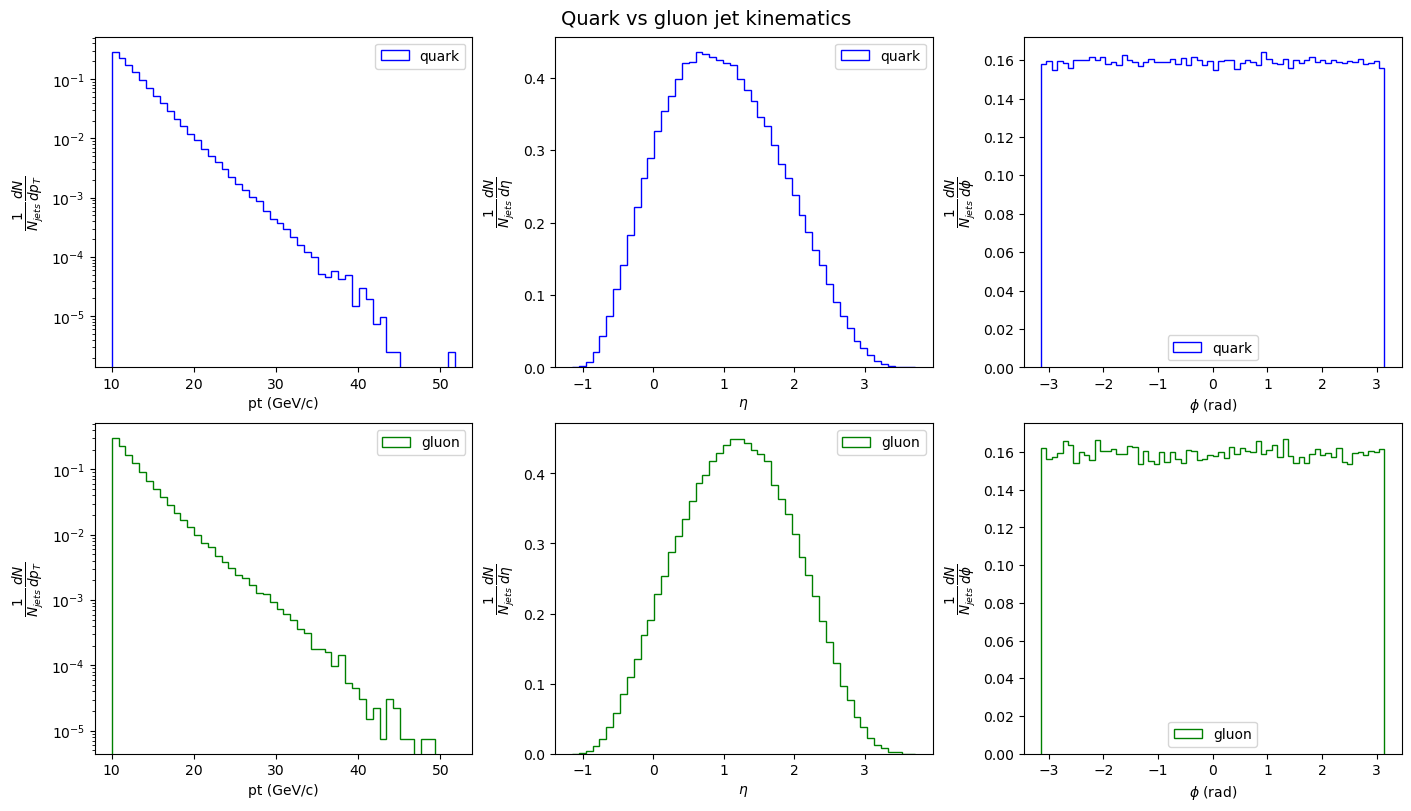

In [ ]:
# --- user constants (tweak if needed) ---
IN_DIR = Path("/home/ajperillo19/anaconda3/envs/EIC_ENV/")  # folder with clustered_##.pkl
N_FILES = 40
IN_PREFIX = "clustered"
IN_EXT = ".pkl"   # change to ".pkl.gz" if compressed

# --- helper: robust open for .pkl or .pkl.gz ---
def open_pickle(path: Path):
    if path.suffix == ".gz":
        with gzip.open(path, "rb") as f:
            return pickle.load(f)
    else:
        with open(path, "rb") as f:
            return pickle.load(f)

# --- safe field extractor for per-event lists
def safe_get(jlist_py, ei, ji):
    if ei < 0 or ei >= len(jlist_py):
        raise IndexError("event index out of range")
    event_jets = jlist_py[ei]
    if event_jets is None:
        raise IndexError("event has no jets")
    # if numpy array
    if isinstance(event_jets, (list, tuple)):
        if ji < 0 or ji >= len(event_jets):
            raise IndexError("jet index out of range")
        return event_jets[ji]
    else:
        # try sequence (numpy array)
        return event_jets[ji]

def wrap_phi(arr):
    a = np.asarray(arr)
    return (a + np.pi) % (2*np.pi) - np.pi

# --- collector function for one batch ---
def collect_from_clustered_obj(obj, min_fraction=0.5):
    """
    obj: loaded pickle (dict or tuple) produced by clustering code.
    Returns: q_pt, q_eta, q_phi, g_pt, g_eta, g_phi  (numpy arrays)
    """

    # Recognize storage format
    # Case A: dict with keys
    if isinstance(obj, dict):
        jpt  = obj.get("jpt")  or obj.get("jets_pt")  or obj.get("pt")  # try common names
        jeta = obj.get("jeta") or obj.get("jets_eta") or obj.get("eta")
        jphi = obj.get("jphi") or obj.get("jets_phi") or obj.get("phi")
        cmother = obj.get("cmother") or obj.get("mother") or obj.get("mp")
    else:
        # Case B: tuple/list
        # (jpt,jeta,jphi,cpt,ceta,cphi,ccharge,cmother,pdg)
        try:
            # try to index safe positions:
            jpt  = obj[0]
            jeta = obj[1]
            jphi = obj[2]
            # cmother might be at position 7 in your earlier tuple
            cmother = obj[7] if len(obj) > 7 else None
        except Exception:
            raise RuntimeError("Unrecognized clustered pickle format. Inspect object keys/length.")

    # convert awkward arrays to python lists-of-lists if needed
    if isinstance(jpt, ak.highlevel.Array):
        jpt_py  = ak.to_list(jpt)
    else:
        jpt_py = list(jpt)

    if isinstance(jeta, ak.highlevel.Array):
        jeta_py = ak.to_list(jeta)
    else:
        jeta_py = list(jeta)

    if isinstance(jphi, ak.highlevel.Array):
        jphi_py = wrap_phi(ak.to_numpy(ak.flatten(jphi)))  # flatten then wrap, but we need per-jet indexing below
        # Better: convert to list-of-lists
        jphi_py = ak.to_list(jphi)
    else:
        jphi_py = list(jphi)

    # cmother should be list-of-events -> list-of-jets -> list-of-int mothers
    # classify_cmother expects cmother like that (it internally used ak.to_list)
    # so pass cmother (convert to python lists if awkward)
    if isinstance(cmother, ak.highlevel.Array):
        cmother_py = ak.to_list(cmother)
    else:
        cmother_py = list(cmother) if cmother is not None else []

    # classify jets using your function
    result = classify_cmother(cmother_py, min_fraction=min_fraction)

    # get indices lists as plain python lists
    quark_indices = list(result["quark_indices"])
    gluon_indices = list(result["gluon_indices"])

    # helper to collect pt/eta/phi using indices
    def collect(indices, jpt_py, jeta_py, jphi_py):
        pts = []
        etas = []
        phis = []
        for idx in indices:
            # idx might be (event_idx, jet_idx)
            try:
                ei, ji = int(idx[0]), int(idx[1])
            except Exception:
                # fallback: try int as event index, jet 0
                ei, ji = int(idx), 0
            try:
                pt_v = float(safe_get(jpt_py, ei, ji))
                eta_v= float(safe_get(jeta_py, ei, ji))
                phi_v= float(safe_get(jphi_py, ei, ji))
            except Exception:
                # skip problematic entries
                continue
            pts.append(pt_v); etas.append(eta_v); phis.append(phi_v)
        return np.array(pts), np.array(etas), wrap_phi(np.array(phis))

    q_pt, q_eta, q_phi = collect(quark_indices, jpt_py, jeta_py, jphi_py)
    g_pt, g_eta, g_phi = collect(gluon_indices, jpt_py, jeta_py, jphi_py)

    return q_pt, q_eta, q_phi, g_pt, g_eta, g_phi

# --- MAIN: loop over files, accumulate ---
master_q_pt = []
master_q_eta = []
master_q_phi = []
master_g_pt = []
master_g_eta = []
master_g_phi = []

for i in range(N_FILES):
    fn = IN_DIR / f"{IN_PREFIX}_{i:02d}{IN_EXT}"
    if not fn.exists():
        print("Missing:", fn); continue

    print("Processing", fn.name)
    obj = open_pickle(fn)
    q_pt, q_eta, q_phi, g_pt, g_eta, g_phi = collect_from_clustered_obj(obj, min_fraction=0.5)

    # append to master lists
    if q_pt.size:
        master_q_pt.extend(q_pt.tolist()); master_q_eta.extend(q_eta.tolist()); master_q_phi.extend(q_phi.tolist())
    if g_pt.size:
        master_g_pt.extend(g_pt.tolist()); master_g_eta.extend(g_eta.tolist()); master_g_phi.extend(g_phi.tolist())

    # free memory
    del obj

# convert to numpy arrays
master_q_pt  = np.array(master_q_pt)
master_q_eta = np.array(master_q_eta)
master_q_phi = np.array(master_q_phi)

master_g_pt  = np.array(master_g_pt)
master_g_eta = np.array(master_g_eta)
master_g_phi = np.array(master_g_phi)

print("Total quark jets:", len(master_q_pt), "Total gluon jets:", len(master_g_pt))

# --- Plot aggregated probability-density histograms ---
# choose bin edges suitable for the combined datasets
bins_pt  = np.histogram_bin_edges(np.concatenate([master_q_pt, master_g_pt]) if (master_q_pt.size or master_g_pt.size) else np.array([0.,1.]), bins=50)
bins_eta = np.histogram_bin_edges(np.concatenate([master_q_eta, master_g_eta]) if (master_q_eta.size or master_g_eta.size) else np.array([-1.,1.]), bins=50)
bins_phi = np.linspace(-np.pi, np.pi, 65)  # fixed, uniform

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

# quark row
if master_q_pt.size:
    axes[0,0].hist(master_q_pt, bins=bins_pt, density=True, histtype='step', alpha=0.9999999, edgecolor='blue', label='quark')
axes[0,0].set_yscale('log'); axes[0,0].set_xlabel('pt (GeV/c)'); axes[0,0].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{dp_T}$', fontsize = 14); axes[0,0].legend()

if master_q_eta.size:
    axes[0,1].hist(master_q_eta, bins=bins_eta, density=True, histtype='step', alpha=0.9999999, edgecolor='blue', label='quark')
axes[0,1].set_xlabel(r'$\eta$'); axes[0,1].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{d\eta}$', fontsize = 14); axes[0,1].legend()

if master_q_phi.size:
    axes[0,2].hist(master_q_phi, bins=bins_phi, density=True, histtype='step', alpha=0.9999999, edgecolor='blue', label='quark')
axes[0,2].set_xlabel(r'$\phi$ (rad)'); axes[0,2].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{d\phi}$', fontsize = 14); axes[0,2].legend()

# gluon row
if master_g_pt.size:
    axes[1,0].hist(master_g_pt, bins=bins_pt, density=True, histtype='step', alpha=0.9999999, edgecolor='green', label='gluon')
axes[1,0].set_yscale('log'); axes[1,0].set_xlabel('pt (GeV/c)'); axes[1,0].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{dp_T}$', fontsize = 14); axes[1,0].legend()

if master_g_eta.size:
    axes[1,1].hist(master_g_eta, bins=bins_eta, density=True, histtype='step', alpha=0.9999999, edgecolor='green', label='gluon')
axes[1,1].set_xlabel(r'$\eta$'); axes[1,1].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{d\eta}$', fontsize = 14); axes[1,1].legend()

if master_g_phi.size:
    axes[1,2].hist(master_g_phi, bins=bins_phi, density=True, histtype='step', alpha=0.9999999, edgecolor='green', label='gluon')
axes[1,2].set_xlabel(r'$\phi$ (rad)'); axes[1,2].set_ylabel(r'$\frac{1}{N_{jets}}\frac{dN}{d\phi}$', fontsize = 14); axes[1,2].legend()

plt.suptitle("Quark vs gluon jet kinematics", fontsize=14)
plt.savefig("Qg_jet_kin.png")
plt.show()

In [14]:
# --- Helpers ---
def _safe_get(jlist_py, ei, ji):
    """Return jlist_py[ei][ji] or raise IndexError if out of range."""
    # jlist_py must be list of per-event iterables
    if ei < 0 or ei >= len(jlist_py):
        raise IndexError(f"event index {ei} out of range (0..{len(jlist_py)-1})")
    event_jets = jlist_py[ei]
    # allow None or empty event
    if event_jets is None:
        raise IndexError(f"event {ei} has no jets (None).")
    # if numpy array inside, convert to list access
    # but indexing into numpy arrays using ji works too
    if isinstance(event_jets, list):
        if ji < 0 or ji >= len(event_jets):
            raise IndexError(f"jet index {ji} out of range for event {ei} (0..{len(event_jets)-1})")
        return event_jets[ji]
    else:
        # try sequence (numpy array or tuple)
        try:
            return event_jets[ji]
        except Exception as e:
            raise IndexError(f"could not access jet {ji} in event {ei}: {e}")

# --- New function: flat-density histograms ---
def extract_and_plot_quark_gluon_eventfractions(
    jpt, jeta, jphi,
    quark_indices,
    gluon_indices,
    bins_pt=50, bins_eta=50, bins_phi=50,
    pt_log_y=True,
    savefile="quark_gluon_histograms_density.png"
):
    """
    Collect quark/gluon jet kinematics from (event,jet) index lists and plot 6 histograms
    with density=True (probability density). Returns collected arrays and bin edges.
    """
    # Convert awkward arrays (or numpy/lists) to python nested lists for safe indexing
    jpt_py  = ak.to_list(jpt)
    jeta_py = ak.to_list(jeta)
    jphi_py = ak.to_list(jphi)

    # --- collector for flat arrays ---
    def collect_flat(indices, var):
        vals = []
        used = 0
        skipped = 0
        for idx in indices:
            if isinstance(idx, (list, tuple)) and len(idx) == 2:
                ei, ji = int(idx[0]), int(idx[1])
            else:
                # fallback: interpret single int as (event_idx, 0)
                try:
                    ei = int(idx)
                    ji = 0
                except Exception:
                    skipped += 1
                    continue
            try:
                if var == "pt":
                    v = float(_safe_get(jpt_py, ei, ji))
                elif var == "eta":
                    v = float(_safe_get(jeta_py, ei, ji))
                elif var == "phi":
                    v = float(_safe_get(jphi_py, ei, ji))
                else:
                    raise ValueError("var must be 'pt','eta' or 'phi'")
                vals.append(v)
                used += 1
            except IndexError:
                skipped += 1
            except Exception:
                skipped += 1
        return np.array(vals), used, skipped

    # collect flat arrays
    q_pt, q_used_pt, q_skipped_pt = collect_flat(quark_indices, "pt")
    q_eta, q_used_eta, q_skipped_eta = collect_flat(quark_indices, "eta")
    q_phi, q_used_phi, q_skipped_phi = collect_flat(quark_indices, "phi")

    g_pt, g_used_pt, g_skipped_pt = collect_flat(gluon_indices, "pt")
    g_eta, g_used_eta, g_skipped_eta = collect_flat(gluon_indices, "eta")
    g_phi, g_used_phi, g_skipped_phi = collect_flat(gluon_indices, "phi")

    print(f"Collected: quark pt {q_used_pt} (skipped {q_skipped_pt}); gluon pt {g_used_pt} (skipped {g_skipped_pt})")


    # --- shared bin edges (so quark & gluon compare on same grid) ---
    def shared_bin_edges(flat_a, flat_b, nbins):
        combined = np.concatenate([flat_a, flat_b]) if (flat_a.size or flat_b.size) else np.array([])
        if combined.size == 0:
            return np.linspace(0, 1, nbins+1)
        return np.histogram_bin_edges(combined, bins=nbins)

    bins_pt_edges  = shared_bin_edges(q_pt, g_pt, bins_pt)
    bins_eta_edges = shared_bin_edges(q_eta, g_eta, bins_eta)
    bins_phi_edges = shared_bin_edges(q_phi, g_phi, bins_phi)

    # --- plotting ---
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

    # quark row
    ax = axes[0,0]
    if q_pt.size:
        ax.hist(q_pt, bins=bins_pt_edges, density=True,alpha = 1, histtype='step', edgecolor='blue')
    ax.set_xlabel('pt (GeV/c)'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{dp_t}$ (log)' , fontsize = 12); ax.set_title('Quark jets: pt')
    if pt_log_y:
        ax.set_yscale('log')
    ax.legend()

    ax = axes[0,1]
    if q_eta.size:
        ax.hist(q_eta, bins=bins_eta_edges, density=True,alpha = 1, histtype='step', edgecolor='blue')
    ax.set_xlabel('$\eta$'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \eta}$', fontsize = 12); ax.set_title('Quark jets: $\eta$')
    ax.legend()

    ax = axes[0,2]
    if q_phi.size:
        ax.hist(q_phi, bins=bins_phi_edges, density=True,alpha = 1, histtype='step', edgecolor='blue')
    ax.set_xlabel('$\phi$ (rad)'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \phi}$', fontsize = 12); ax.set_title('Quark jets: $\phi$')
    ax.legend()

    # gluon row
    ax = axes[1,0]
    if g_pt.size:
        ax.hist(g_pt, bins=bins_pt_edges, color = 'green', density=True, alpha = 1, histtype='step', edgecolor='green')
    ax.set_xlabel('pt (GeV/c)'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{dp_t}$ (log)'  , fontsize = 12); ax.set_title('Gluon jets: pt')
    if pt_log_y:
        ax.set_yscale('log')
    ax.legend()

    ax = axes[1,1]
    if g_eta.size:
        ax.hist(g_eta, bins=bins_eta_edges, color = 'green', density=True, alpha = 1, histtype='step', edgecolor='green')
    ax.set_xlabel('$\eta$'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \eta}$', fontsize = 12); ax.set_title('Gluon jets: $\eta$')
    ax.legend()

    ax = axes[1,2]
    if g_phi.size:
        ax.hist(g_phi, bins=bins_phi_edges, color = 'green', density=True, alpha = 1, histtype='step', edgecolor='green')
    ax.set_xlabel('$\phi$ (rad)'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \phi}$', fontsize = 12); ax.set_title('Gluon jets: $\phi$')
    ax.legend()

    plt.suptitle("Quark vs Gluon jet kinematics", fontsize=14)
    plt.show()

    if savefile:
        fig.savefig(savefile, dpi=200, bbox_inches='tight')
        print(f"Saved {savefile}")

    # return collected data and bin edges
    return {
        "quark": {"pt": q_pt, "eta": q_eta, "phi": q_phi},
        "gluon": {"pt": g_pt, "eta": g_eta, "phi": g_phi},
        "bins": {"pt_edges": bins_pt_edges, "eta_edges": bins_eta_edges, "phi_edges": bins_phi_edges}
    }

<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:119: SyntaxWarning: invalid escape sequence '\p'
<>:119: SyntaxWarning: invalid escape sequence '\p'
<>:134: SyntaxWarning: invalid escape sequence '\e'
<>:134: SyntaxWarning: invalid escape sequence '\e'
<>:140: SyntaxWarning: invalid escape sequence '\p'
<>:140: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\e'
<>:119: SyntaxWarning: invalid escape sequence '\p'
<>:119: SyntaxWarning: invalid escape sequence '\p'
<>:134: SyntaxWarning: invalid escape sequence '\e'
<>:134: SyntaxWarning: invalid escape sequence '\e'
<>:140: SyntaxWarning: invalid escape sequence '\p'
<>:140: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_246427/888836353.py:113: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\eta$'); ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \eta}$', 

In [ ]:
def wrap_dphi(dphi):
    """Wrap angular difference into [-pi, pi]."""
    return (dphi + np.pi) % (2*np.pi) - np.pi

def idx_to_ej(idx):
    if isinstance(idx, (list, tuple)) and len(idx) == 2:
        return int(idx[0]), int(idx[1])
    else:
        return int(idx), 0

def lambda_for_index(
    ei:int, ji:int,
    jpt_py, jeta_py, jphi_py,
    cpt_py, ceta_py, cphi_py,
    kappa:float, beta:float, R:float = 0.4
) -> float | None:
    """Return lambda_{kappa,beta} for jet (ei,ji) or None if not computable."""
    try:
        jet_pt  = float(_safe_get(jpt_py,  ei, ji))
        jet_eta = float(_safe_get(jeta_py, ei, ji))
        jet_phi = float(_safe_get(jphi_py, ei, ji))
        cons_pt  = np.asarray(_safe_get(cpt_py,  ei, ji))
        cons_eta = np.asarray(_safe_get(ceta_py, ei, ji))
        cons_phi = np.asarray(_safe_get(cphi_py, ei, ji))
    except Exception:
        return None

    # require at least 2 constituents (same behavior as your previous code)
    if cons_pt.size < 2 or jet_pt <= 0:
        return None

    z = cons_pt / jet_pt
    deta = cons_eta - jet_eta
    dphi = wrap_dphi(cons_phi - jet_phi)
    dR = np.sqrt(deta**2 + dphi**2)
    lam = np.sum((z ** kappa) * ((dR / R) ** beta))
    return float(lam)

def compute_lambdas_for_indices(
    jpt, jeta, jphi, cpt, ceta, cphi,
    indices: List[Tuple[int,int]],
    kappa: float, beta: float, R: float = 0.4
) -> np.ndarray:
    """Return numpy array of lambda values for the given (event,jet) indices."""
    # convert awkward arrays to python lists if necessary
    jpt_py  = ak.to_list(jpt)   if not isinstance(jpt, list)  else jpt
    jeta_py = ak.to_list(jeta)  if not isinstance(jeta, list)  else jeta
    jphi_py = ak.to_list(jphi)  if not isinstance(jphi, list)  else jphi
    cpt_py  = ak.to_list(cpt)   if not isinstance(cpt, list)  else cpt
    ceta_py = ak.to_list(ceta)  if not isinstance(ceta, list)  else ceta
    cphi_py = ak.to_list(cphi)  if not isinstance(cphi, list)  else cphi

    vals = []
    for idx in indices:
        ei, ji = idx_to_ej(idx)
        lam = lambda_for_index(ei, ji, jpt_py, jeta_py, jphi_py, cpt_py, ceta_py, cphi_py, kappa, beta, R)
        if lam is not None:
            vals.append(lam)
    arr = np.asarray(vals)
    # remove exact zeros (keeps your prior behavior)
    if arr.size:
        arr = arr[arr != 0]
    return arr

def run_kappa_beta_2x2_sharedbins(
    jpt, jeta, jphi, cpt, ceta, cphi,
    quark_indices, gluon_indices,
    kappa_vals: Tuple[float,float,float,float] = (0.25, 0.5, 0.75, 1.0),
    beta_vals:  Tuple[float,float,float,float] = (0.25, 0.5, 0.75, 1.0),
    R: float = 0.4,
    bins: int = 50,
    density: bool = True,
    save_prefix: str | None = None
) -> Dict[str, Any]:
    """
    Produce two 2x2 figures:
      - Kappa scan (beta fixed = 1.0) where the four kappa panels share the same bin edges.
      - Beta  scan (kappa fixed = 1.0) where the four beta  panels share the same bin edges.

    Returns a dict:
      { 'kappa_scan': {kappa: {'q_lambda', 'g_lambda'} ...}, 'kappa_bins': array, 
        'beta_scan': {beta: {...}}, 'beta_bins': array }
    """
    # --- KAPPA SCAN (beta fixed = 1.0) ---
    beta_fixed = 1.0
    kappa_results = {}
    combined_kappa_vals = []

    # compute per-kappa arrays first
    for kappa in kappa_vals:
        q_arr = compute_lambdas_for_indices(jpt, jeta, jphi, cpt, ceta, cphi, quark_indices, kappa, beta_fixed, R)
        g_arr = compute_lambdas_for_indices(jpt, jeta, jphi, cpt, ceta, cphi, gluon_indices, kappa, beta_fixed, R)
        kappa_results[kappa] = {"q_lambda": q_arr, "g_lambda": g_arr}
        if q_arr.size:
            combined_kappa_vals.append(q_arr)
        if g_arr.size:
            combined_kappa_vals.append(g_arr)

    # choose shared bin edges for all kappa panels
    if len(combined_kappa_vals) > 0:
        combined_kappa = np.concatenate(combined_kappa_vals)
        kappa_bins = np.histogram_bin_edges(combined_kappa, bins=bins)
    else:
        kappa_bins = np.linspace(0, 1, bins + 1)

    # Plot kappa scan on 2x2 grid using shared kappa_bins
    fig1, axes1 = plt.subplots(2, 2, figsize=(12, 9))
    axes1 = axes1.flatten()
    for idx, kappa in enumerate(kappa_vals):
        ax = axes1[idx]
        q_arr = kappa_results[kappa]["q_lambda"]
        g_arr = kappa_results[kappa]["g_lambda"]

        plotted = False
        if q_arr.size:
            ax.hist(q_arr, bins=kappa_bins, density=density, histtype='step', edgecolor='blue', alpha = 1 ,label='quark')
            plotted = True
        if g_arr.size:
            ax.hist(g_arr, bins=kappa_bins, density=density, histtype='step', edgecolor='green', alpha = 1, label='gluon')
            plotted = True
        if not plotted:
            ax.text(0.5,0.5,"no data", ha='center', va='center')

        ax.set_title(fr'$\kappa$={kappa:.2f}, $\beta$={beta_fixed:.2f}')
        ax.set_xlabel((fr'$\lambda_{{{kappa:.2f},{beta_fixed:.2f}}}$'), fontsize = 14)
        ax.set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$' if density else 'Counts', fontsize = 14)
        ax.grid(alpha=0.12)
        ax.legend(fontsize=9)
    # turn off any unused axes (shouldn't be any)
    for j in range(len(kappa_vals), 4):
        axes1[j].axis('off')

    plt.suptitle('Effect of varying $\kappa$', fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    if save_prefix:
        fig1.savefig(f"{save_prefix}_kappa_sharedbins_2x2.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig1)

    # --- BETA SCAN (kappa fixed = 1.0) ---
    kappa_fixed = 1.0
    beta_results = {}
    combined_beta_vals = []

    for beta in beta_vals:
        q_arr = compute_lambdas_for_indices(jpt, jeta, jphi, cpt, ceta, cphi, quark_indices, kappa_fixed, beta, R)
        g_arr = compute_lambdas_for_indices(jpt, jeta, jphi, cpt, ceta, cphi, gluon_indices, kappa_fixed, beta, R)
        beta_results[beta] = {"q_lambda": q_arr, "g_lambda": g_arr}
        if q_arr.size:
            combined_beta_vals.append(q_arr)
        if g_arr.size:
            combined_beta_vals.append(g_arr)

    if len(combined_beta_vals) > 0:
        combined_beta = np.concatenate(combined_beta_vals)
        beta_bins = np.histogram_bin_edges(combined_beta, bins=bins)
    else:
        beta_bins = np.linspace(0, 1, bins + 1)

    # Plot beta scan on 2x2 grid using shared beta_bins
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 9))
    axes2 = axes2.flatten()
    for idx, beta in enumerate(beta_vals):
        ax = axes2[idx]
        q_arr = beta_results[beta]["q_lambda"]
        g_arr = beta_results[beta]["g_lambda"]

        plotted = False
        if q_arr.size:
            ax.hist(q_arr, bins=beta_bins, density=density, histtype='step', edgecolor='blue', alpha = .9999999, label='quark')
            plotted = True
        if g_arr.size:
            ax.hist(g_arr, bins=beta_bins, density=density, histtype='step', edgecolor='green', alpha = .9999999, label='gluon')
            plotted = True
        if not plotted:
            ax.text(0.5,0.5,"no data", ha='center', va='center')

        ax.set_title(fr'$\kappa$={kappa_fixed:.2f}, $\beta$={beta:.2f}')
        ax.set_xlabel((fr'$\lambda_{{{kappa_fixed:.2f},{beta:.2f}}}$'), fontsize = 14)
        ax.set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$' if density else 'Counts', fontsize = 14)
        ax.grid(alpha=0.12)
        ax.legend(fontsize=9)
    for j in range(len(beta_vals), 4):
        axes2[j].axis('off')

    plt.suptitle(r'Effect of varying $\beta$', fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    if save_prefix:
        fig2.savefig(f"{save_prefix}_beta_sharedbins_2x2.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig2)

    # return all results and the shared bin edges
    return {
        "kappa_scan": kappa_results,
        "kappa_bins": kappa_bins,
        "beta_scan": beta_results,
        "beta_bins": beta_bins
    }

<>:133: SyntaxWarning: invalid escape sequence '\k'
<>:133: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_246427/135675522.py:133: SyntaxWarning: invalid escape sequence '\k'
  plt.suptitle('Effect of varying $\kappa$', fontsize=14)


Processing clustered_00.pkl
Processing clustered_01.pkl
Processing clustered_02.pkl
Processing clustered_03.pkl
Processing clustered_04.pkl
Processing clustered_05.pkl
Processing clustered_06.pkl
Processing clustered_07.pkl
Processing clustered_08.pkl
Processing clustered_09.pkl
Processing clustered_10.pkl
Processing clustered_11.pkl
Processing clustered_12.pkl
Processing clustered_13.pkl
Processing clustered_14.pkl
Processing clustered_15.pkl
Processing clustered_16.pkl
Processing clustered_17.pkl
Processing clustered_18.pkl
Processing clustered_19.pkl
Processing clustered_20.pkl
Processing clustered_21.pkl
Processing clustered_22.pkl
Processing clustered_23.pkl
Processing clustered_24.pkl
Processing clustered_25.pkl
Processing clustered_26.pkl
Processing clustered_27.pkl
Processing clustered_28.pkl
Processing clustered_29.pkl
Processing clustered_30.pkl
Processing clustered_31.pkl
Processing clustered_32.pkl
Processing clustered_33.pkl
Processing clustered_34.pkl
Processing clustered

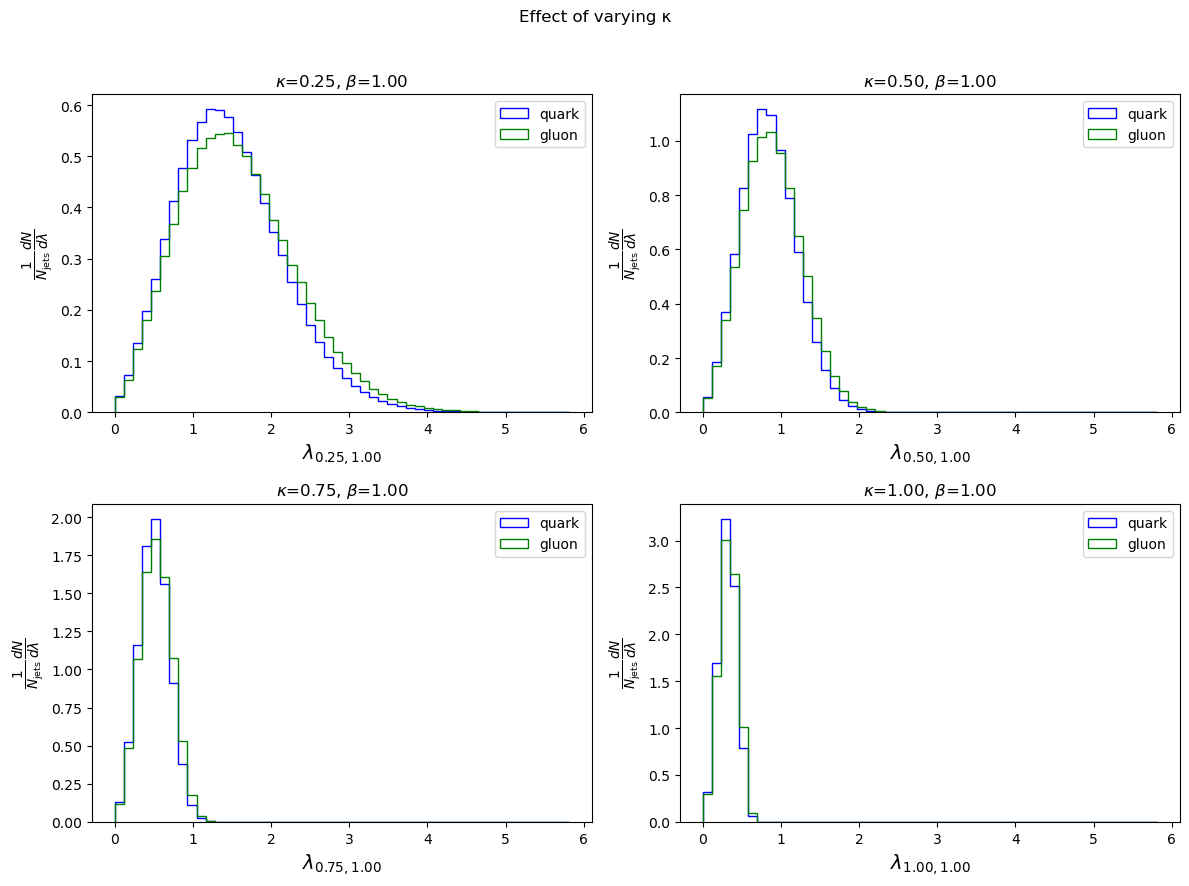

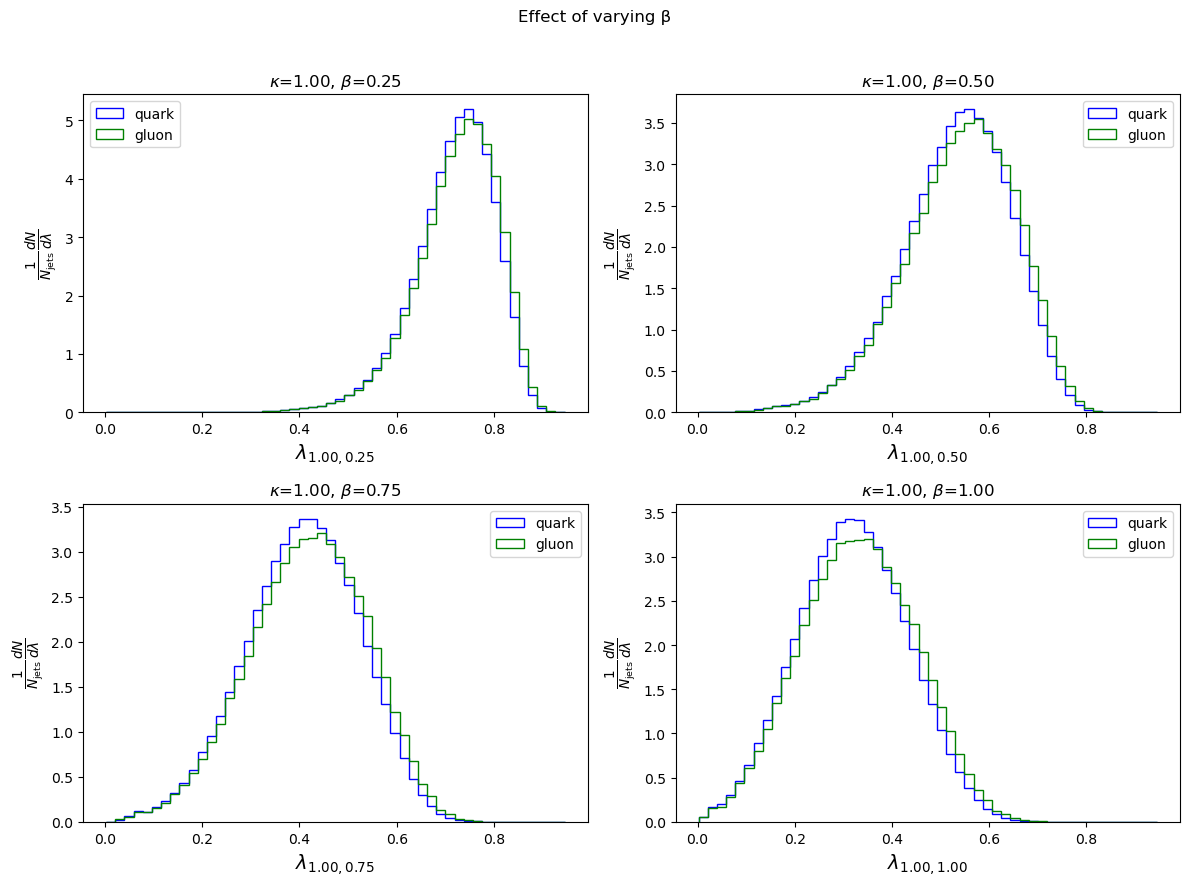

In [16]:
# ---------- SETTINGS ----------
DATA_DIR = Path("/home/ajperillo19/anaconda3/envs/EIC_ENV")   # adjust to folder containing clustered_XX.pkl
PREFIX = "clustered"
EXT = ".pkl"   # use ".pkl.gz" if gzip-compressed
N_FILES = 40   # 00..39
MIN_FRACTION = 0.5

# ---------- file opener that supports gzip ----------
def open_pickle(path: Path):
    if path.suffix == ".gz":
        with gzip.open(path, "rb") as f:
            return pickle.load(f)
    else:
        with open(path, "rb") as f:
            return pickle.load(f)

# ---------- small helper to ensure indices format ----------
def idx_to_pair(idx):
    if isinstance(idx, (list, tuple)) and len(idx) == 2:
        return int(idx[0]), int(idx[1])
    else:
        return int(idx), 0

# ---------- compute_lambdas_for_indices and lambda_for_index --------- #

# ---------- AGGREGATORS: create containers for kappa & beta scans ----------
kappa_vals = (0.25, 0.5, 0.75, 1.0)
beta_vals  = (0.25, 0.5, 0.75, 1.0)
R = 0.4
bins = 50
density = True

# dicts mapping param -> list of arrays (we'll extend)
agg_kappa_q = {k: [] for k in kappa_vals}
agg_kappa_g = {k: [] for k in kappa_vals}

agg_beta_q = {b: [] for b in beta_vals}
agg_beta_g = {b: [] for b in beta_vals}

# ---------- main loop over clustered files ----------
for i in range(N_FILES):
    fname = DATA_DIR / f"{PREFIX}_{i:02d}{EXT}"
    if not fname.exists():
        print("Missing", fname); continue
    print("Processing", fname.name)

    obj = open_pickle(fname)

    # --- extract expected FinalStateCluster members ---
    # Two common formats: tuple (jpt,jeta,jphi,cpt,ceta,cphi,...) or dict with keys
    jpt = jeta = jphi = cpt = ceta = cphi = cmother = None
    if isinstance(obj, (list, tuple)) and len(obj) >= 8:
        jpt, jeta, jphi, cpt, ceta, cphi = obj[0], obj[1], obj[2], obj[3], obj[4], obj[5]
        # cmother might be at index 7 or 8 depending on how you saved
        try:
            cmother = obj[7]
        except Exception:
            cmother = None
    elif isinstance(obj, dict):
        jpt  = obj.get("jpt")  or obj.get("pt")    or obj.get("jets_pt")
        jeta = obj.get("jeta") or obj.get("eta")   or obj.get("jets_eta")
        jphi = obj.get("jphi") or obj.get("phi")   or obj.get("jets_phi")
        cpt  = obj.get("cpt")  or obj.get("const_pt")
        ceta = obj.get("ceta") or obj.get("const_eta")
        cphi = obj.get("cphi") or obj.get("const_phi")
        cmother = obj.get("cmother") or obj.get("mp") or obj.get("mother")
    else:
        raise RuntimeError("Unrecognized clustered file object type; inspect object")

    # convert awkward arrays to python lists for classify function
    # (classify_cmother expects nested lists of ints)
    try:
        cmother_py = ak.to_list(cmother) if isinstance(cmother, ak.highlevel.Array) else list(cmother)
    except Exception:
        # fallback if already list-like
        cmother_py = cmother

    # classify jets by mother
    result = classify_cmother(cmother_py, min_fraction=MIN_FRACTION)
    quark_indices = result["quark_indices"]
    gluon_indices = result["gluon_indices"]

    # convert j/c arrays to python lists for lambda computation (compute_lambdas_for_indices expects these)
    jpt_py  = ak.to_list(jpt)  if isinstance(jpt, ak.highlevel.Array) else list(jpt)
    jeta_py = ak.to_list(jeta) if isinstance(jeta, ak.highlevel.Array) else list(jeta)
    jphi_py = ak.to_list(jphi) if isinstance(jphi, ak.highlevel.Array) else list(jphi)
    cpt_py  = ak.to_list(cpt)  if isinstance(cpt, ak.highlevel.Array) else list(cpt)
    ceta_py = ak.to_list(ceta) if isinstance(ceta, ak.highlevel.Array) else list(ceta)
    cphi_py = ak.to_list(cphi) if isinstance(cphi, ak.highlevel.Array) else list(cphi)

    # --- compute lambdas for all kappa (beta_fixed = 1.0) and aggregate ---
    beta_fixed = 1.0
    for k in kappa_vals:
        q_arr = compute_lambdas_for_indices(jpt_py, jeta_py, jphi_py, cpt_py, ceta_py, cphi_py, quark_indices, k, beta_fixed, R)
        g_arr = compute_lambdas_for_indices(jpt_py, jeta_py, jphi_py, cpt_py, ceta_py, cphi_py, gluon_indices, k, beta_fixed, R)
        if q_arr.size:
            agg_kappa_q[k].append(q_arr)
        if g_arr.size:
            agg_kappa_g[k].append(g_arr)

    # --- compute lambdas for all beta (kappa_fixed = 1.0) and aggregate ---
    kappa_fixed = 1.0
    for b in beta_vals:
        q_arr = compute_lambdas_for_indices(jpt_py, jeta_py, jphi_py, cpt_py, ceta_py, cphi_py, quark_indices, kappa_fixed, b, R)
        g_arr = compute_lambdas_for_indices(jpt_py, jeta_py, jphi_py, cpt_py, ceta_py, cphi_py, gluon_indices, kappa_fixed, b, R)
        if q_arr.size:
            agg_beta_q[b].append(q_arr)
        if g_arr.size:
            agg_beta_g[b].append(g_arr)

    # free memory
    del obj

# ---------- concatenate aggregated arrays across files ----------
for k in kappa_vals:
    if len(agg_kappa_q[k]):
        agg_kappa_q[k] = np.concatenate(agg_kappa_q[k])
    else:
        agg_kappa_q[k] = np.array([])
    if len(agg_kappa_g[k]):
        agg_kappa_g[k] = np.concatenate(agg_kappa_g[k])
    else:
        agg_kappa_g[k] = np.array([])

for b in beta_vals:
    if len(agg_beta_q[b]):
        agg_beta_q[b] = np.concatenate(agg_beta_q[b])
    else:
        agg_beta_q[b] = np.array([])
    if len(agg_beta_g[b]):
        agg_beta_g[b] = np.concatenate(agg_beta_g[b])
    else:
        agg_beta_g[b] = np.array([])

# ---------- build shared bins (kappa scan and beta scan separately) ----------
# Kappa shared bins (combine all q and g for kappa-scan)
combined_kappa_all = np.concatenate([v for v in list(agg_kappa_q.values()) + list(agg_kappa_g.values()) if v.size])
if combined_kappa_all.size:
    kappa_bins = np.histogram_bin_edges(combined_kappa_all, bins=bins)
else:
    kappa_bins = np.linspace(0,1,bins+1)

# Beta shared bins (combine all q and g for beta-scan)
combined_beta_all = np.concatenate([v for v in list(agg_beta_q.values()) + list(agg_beta_g.values()) if v.size])
if combined_beta_all.size:
    beta_bins = np.histogram_bin_edges(combined_beta_all, bins=bins)
else:
    beta_bins = np.linspace(0,1,bins+1)

# ---------- Plot kappa 2x2 (shared bins) ----------
fig_k, axes_k = plt.subplots(2,2, figsize=(12,9))
axes_k = axes_k.flatten()
for idx,k in enumerate(kappa_vals):
    ax = axes_k[idx]
    qv = agg_kappa_q[k]; gv = agg_kappa_g[k]
    plotted = False
    if qv.size:
        ax.hist(qv, bins=kappa_bins, density=density, histtype='step', edgecolor='blue', label='quark')
        plotted = True
    if gv.size:
        ax.hist(gv, bins=kappa_bins, density=density, histtype='step', edgecolor='green', label='gluon')
        plotted = True
    if not plotted:
        ax.text(0.5,0.5,"no data", ha='center', va='center')
    ax.set_title(fr'$\kappa$={k:.2f}, $\beta$={beta_fixed:.2f}')
    ax.set_xlabel((fr'$\lambda_{{{k:.2f},{beta_fixed:.2f}}}$'), fontsize = 14); ax.set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$', fontsize = 14)
    ax.legend()
plt.suptitle('Effect of varying κ')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# ---------- Plot beta 2x2 (shared bins) ----------
fig_b, axes_b = plt.subplots(2,2, figsize=(12,9))
axes_b = axes_b.flatten()
for idx,b in enumerate(beta_vals):
    ax = axes_b[idx]
    qv = agg_beta_q[b]; gv = agg_beta_g[b]
    plotted = False
    if qv.size:
        ax.hist(qv, bins=beta_bins, density=density, histtype='step', edgecolor='blue', label='quark')
        plotted = True
    if gv.size:
        ax.hist(gv, bins=beta_bins, density=density, histtype='step', edgecolor='green', label='gluon')
        plotted = True
    if not plotted:
        ax.text(0.5,0.5,"no data", ha='center', va='center')
    ax.set_title(fr'$\kappa$={kappa_fixed:.2f}, $\beta$={b:.2f}')
    ax.set_xlabel((fr'$\lambda_{{{kappa_fixed:.2f},{b:.2f}}}$'), fontsize = 14); ax.set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$', fontsize = 14)
    ax.legend()
plt.suptitle('Effect of varying β') 
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('qg_jets.png')
plt.show()

# ---------- results dictionary to inspect later ----------
results = {
    "agg_kappa_q": agg_kappa_q,
    "agg_kappa_g": agg_kappa_g,
    "kappa_bins": kappa_bins,
    "agg_beta_q": agg_beta_q,
    "agg_beta_g": agg_beta_g,
    "beta_bins": beta_bins
}

In [17]:
flat_jpt = ak.concatenate(jpt)
flat_jeta = ak.concatenate(jeta)
flat_jphi = ak.concatenate(jphi)

# concatenate constituent particle awkward arrays
flat_cpt = ak.concatenate(cpt)
flat_ceta = ak.concatenate(ceta)
flat_cphi = ak.concatenate(cphi)

In [18]:
def analyze_and_plot_jets_density(jpt, jeta, jphi,
                                  bins_pt=20, bins_eta=20, bins_phi=20,
                                  bins_dphi=20, pt_log_y=True,
                                  savefile_prefix=None):
    """
    Analyze jet collections (awkward arrays) and plot density=True histograms:
      - compares all jets vs jets from dijet events (overlayed)
      - plots delta-phi (inclusive top-2 jets per event and exact dijet events)
      - plots leading-jet phi distribution

    Parameters
    ----------
    jpt, jeta, jphi : awkward arrays (per-event jet lists)
    bins_pt, bins_eta, bins_phi : int or bin spec for histogram edges
    bins_dphi : bins used for dphi (int)
    pt_log_y : bool -> set log y-axis for pt plots
    savefile_prefix : str or None -> if given, saves files like "{prefix}_pt.png", etc.

    Returns
    -------
    dict with flattened arrays and computed dphi arrays and used bin edges.
    """

    # ---- basic conversions & sanity ----
    # number of jets per event (awkward)
    jet_counts = ak.num(jpt)                   
    N_events = int(ak.to_numpy(ak.count(jet_counts)))  # total events (safe)
    # mask dijet events
    mask_dijet = jet_counts == 2

    # Select only dijet events
    jpt_dijet = jpt[mask_dijet]
    jeta_dijet = jeta[mask_dijet]
    jphi_dijet = jphi[mask_dijet]

    # Flatten to numpy arrays (safe: handle empty)
    def flatten_to_numpy(arr):
        try:
            flat = ak.flatten(arr)
            return ak.to_numpy(flat) if flat.size else np.array([])
        except Exception:
            # fallback: try to_list then numpy
            try:
                lst = ak.to_list(arr)
                flatlist = [x for sub in lst for x in sub] if lst else []
                return np.asarray(flatlist)
            except Exception:
                return np.array([])

    flat_jpt_all   = flatten_to_numpy(jpt)
    flat_jeta_all  = flatten_to_numpy(jeta)
    flat_jphi_all  = flatten_to_numpy(jphi)

    flat_jpt_dijet  = flatten_to_numpy(jpt_dijet)
    flat_jeta_dijet = flatten_to_numpy(jeta_dijet)
    flat_jphi_dijet = flatten_to_numpy(jphi_dijet)

    N_all_jets = len(flat_jpt_all)
    N_dijet_jets = len(flat_jpt_dijet)

    print(f"Total events = {N_events}, total jets = {N_all_jets}, dijet jets = {N_dijet_jets}")

    # ---------------------------
    # 1) Jet multiplicity distribution per event (density=False but normalized per event count shown)
    # ---------------------------
    plt.figure(figsize=(6,4))
    if len(ak.to_numpy(jet_counts))>0:
        counts = ak.to_numpy(jet_counts)
        max_jets = counts.max()
        bins_counts = np.arange(0, max_jets + 2) - 0.5
        weights = np.ones_like(counts) / float(N_events)
        plt.hist(counts, bins=bins_counts, weights=weights, edgecolor='black')
        plt.xticks(np.arange(0, max_jets + 1))
        plt.xlabel("Number of jets per event")
        plt.ylabel("Fraction of events")
        plt.title("Jet multiplicity distribution")
        plt.yscale("log")
        plt.tight_layout()
        if savefile_prefix:
            plt.savefig(f"{savefile_prefix}_jet_multiplicity.png", dpi=200, bbox_inches='tight')
        plt.show()
    else:
        print("No events to plot jet multiplicity.")

    # ---------------------------
    # 2) Comparison histograms: PT, ETA, PHI (density=True)
    # ---------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()

    # helper to determine shared bin edges
    def shared_edges(a, b, nbins):
        a = np.asarray(a) if a is not None else np.array([])
        b = np.asarray(b) if b is not None else np.array([])
        combined = np.concatenate([a, b]) if (a.size or b.size) else np.array([])
        if combined.size == 0:
            return np.linspace(0,1, nbins+1)
        return np.histogram_bin_edges(combined, bins=nbins)

    # PT
    if N_all_jets > 0 or N_dijet_jets > 0:
        bins_pt_edges = shared_edges(flat_jpt_all, flat_jpt_dijet, bins_pt)
        # all jets (density)
        if flat_jpt_all.size:
            axes[0].hist(flat_jpt_all, bins=bins_pt_edges, density=True,
                         histtype='step', alpha=0.9999999, label='All jets', edgecolor='blue')
        # dijet (overlay)
        if flat_jpt_dijet.size:
            axes[0].hist(flat_jpt_dijet, bins=bins_pt_edges, density=True,
                         histtype='step', color='r', label='Dijets', linewidth=1.5)
        axes[0].set_xlabel('Jet $p_T$')
        axes[0].set_ylabel(r'$\frac{1}{N_{cons}} \frac{dN}{dp_t}$ (log)', fontsize = 14)
        if pt_log_y:
            axes[0].set_yscale('log')
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, 'No PT data', ha='center')

    # ETA
    if flat_jeta_all.size or flat_jeta_dijet.size:
        bins_eta_edges = shared_edges(flat_jeta_all, flat_jeta_dijet, bins_eta)
        if flat_jeta_all.size:
            axes[1].hist(flat_jeta_all, bins=bins_eta_edges, density=True,
                         histtype='step', alpha=0.999999, label='All jets', edgecolor='blue')
        if flat_jeta_dijet.size:
            axes[1].hist(flat_jeta_dijet, bins=bins_eta_edges, density=True,
                         histtype='step', color='r', label='Dijets', linewidth=1.5)
        axes[1].set_xlabel('Jet $\\eta$')
        axes[1].set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{\eta}$', fontsize = 14)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'No ETA data', ha='center')

    # PHI
    if flat_jphi_all.size or flat_jphi_dijet.size:
        bins_phi_edges = shared_edges(flat_jphi_all, flat_jphi_dijet, bins_phi)
        if flat_jphi_all.size:
            axes[2].hist(flat_jphi_all, bins=bins_phi_edges, density=True,
                         histtype='step', alpha=0.9999999, label='All jets', edgecolor='blue')
        if flat_jphi_dijet.size:
            axes[2].hist(flat_jphi_dijet, bins=bins_phi_edges, density=True,
                         histtype='step', color='r', alpha = .9999999, label='Dijets', linewidth=1.5)
        axes[2].set_xlabel('Jet $\\phi$ (rad)')
        axes[2].set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{\phi}$', fontsize = 14)
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, 'No PHI data', ha='center')

    # ---------------------------
    # 3) Delta-phi histograms (inclusive top-2 vs exact dijet)
    #    Use density=True so you get probability density for angular separation.
    # ---------------------------
    # compute dphi_dijet: exact two-jet events
    dphi_dijet_list = []
    # compute dphi_incl: top-2 jets by pT in events with >=2 jets
    dphi_incl_list = []
    # We'll iterate using ak.to_list for safety
    jpt_list = ak.to_list(jpt)
    jphi_list = ak.to_list(jphi)
    for pt_event, phi_event in zip(jpt_list, jphi_list):
        if not phi_event:  
            continue
        # convert to numpy array for numeric ops
        phi_event_arr = np.asarray(phi_event)
        pt_event_arr = np.asarray(pt_event) if pt_event else np.array([])
        if len(phi_event_arr) == 2:
            diff = np.abs(phi_event_arr[1] - phi_event_arr[0])
            if diff > np.pi:
                diff = 2*np.pi - diff
            dphi_dijet_list.append(diff)
        if len(phi_event_arr) >= 2 and len(pt_event_arr) >= 2:
            # pick top-2 by pt
            top2 = np.argsort(pt_event_arr)[-2:][::-1]
            phi1 = phi_event_arr[top2[0]]
            phi2 = phi_event_arr[top2[1]]
            diff = np.abs(phi1 - phi2)
            if diff > np.pi:
                diff = 2*np.pi - diff
            dphi_incl_list.append(diff)

    dphi_dijet = np.asarray(dphi_dijet_list)
    dphi_incl = np.asarray(dphi_incl_list)

    bins_dphi_edges = np.linspace(0, np.pi, bins_dphi + 1)

    # Place dphi plot in axes[3]
    if dphi_incl.size or dphi_dijet.size:
        if dphi_incl.size:
            axes[3].hist(dphi_incl, bins=bins_dphi_edges, density=True,
                         histtype='step', alpha=0.9999999, color = 'blue' ,label='Inclusive (≥2 jets)')
        if dphi_dijet.size:
            axes[3].hist(dphi_dijet, bins=bins_dphi_edges, density=True,
                         histtype='step', color='r', alpha = .9999999, label='Dijets')
        axes[3].set_xlabel(r'$\Delta\phi$ (rad)')
        axes[3].set_ylabel(r'$\frac{1}{N_{cons}} \frac{dN}{\Delta \phi}$ (log)', fontsize = 14)
        axes[3].set_yscale('log')
        axes[3].legend()
    else:
        axes[3].text(0.5, 0.5, 'No Δφ data', ha='center')

    plt.suptitle("Jet kinematics", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if savefile_prefix:
        try:
            fig.savefig(f"{savefile_prefix}_summary.png", dpi=200, bbox_inches='tight')
        except Exception as e:
            print(f"Warning: could not save summary figure: {e}")
    plt.show()

    # ---------------------------
    # 4) Leading-jet phi distribution (probability density)
    # ---------------------------
    # Build leading-jet phi list
    lead_phi_list = []
    for pt_event, phi_event in zip(jpt_list, jphi_list):
        if not pt_event:
            continue
        pt_arr = np.asarray(pt_event)
        phi_arr = np.asarray(phi_event)
        idx = int(np.argmax(pt_arr))
        lead_phi_list.append(phi_arr[idx])

    lead_phi = np.asarray(lead_phi_list)
    if lead_phi.size > 0:
        bins_lead = np.linspace(0, np.pi, 36)  # full 0..2pi
        plt.figure(figsize=(6,4))
        plt.hist(lead_phi, bins=bins_lead, density=True, histtype = 'step', edgecolor='blue', alpha=0.9999999)
        plt.xlabel(r'$\phi_{\rm leading}$ (rad)')
        plt.ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{\phi_{leading}}$', fontsize = 14)
        plt.title('Leading‐jet $\phi$ Distribution')
        if savefile_prefix:
            try:
                plt.savefig(f"{savefile_prefix}_leadphi.png", dpi=200, bbox_inches='tight')
            except Exception as e:
                print(f"Warning: could not save lead-phi figure: {e}")
        plt.tight_layout()
        plt.show()
    else:
        print("No leading-phi data to plot.")

    # Return data for later use
    return {
        "N_events": N_events,
        "N_all_jets": N_all_jets,
        "N_dijet_jets": N_dijet_jets,
        "flat_jpt_all": flat_jpt_all,
        "flat_jeta_all": flat_jeta_all,
        "flat_jphi_all": flat_jphi_all,
        "flat_jpt_dijet": flat_jpt_dijet,
        "flat_jeta_dijet": flat_jeta_dijet,
        "flat_jphi_dijet": flat_jphi_dijet,
        "dphi_incl": dphi_incl,
        "dphi_dijet": dphi_dijet,
        "lead_phi": lead_phi,
        "bins": {
            "pt_edges": bins_pt_edges if 'bins_pt_edges' in locals() else None,
            "eta_edges": bins_eta_edges if 'bins_eta_edges' in locals() else None,
            "phi_edges": bins_phi_edges if 'bins_phi_edges' in locals() else None,
            "dphi_edges": bins_dphi_edges
        }
    }

<>:230: SyntaxWarning: invalid escape sequence '\p'
<>:230: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_246427/2002507942.py:230: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Leading‐jet $\phi$ Distribution')


[load] clustered_00.pkl
[load] clustered_01.pkl
[load] clustered_02.pkl
[load] clustered_03.pkl
[load] clustered_04.pkl
[load] clustered_05.pkl
[load] clustered_06.pkl
[load] clustered_07.pkl
[load] clustered_08.pkl
[load] clustered_09.pkl
[load] clustered_10.pkl
[load] clustered_11.pkl
[load] clustered_12.pkl
[load] clustered_13.pkl
[load] clustered_14.pkl
[load] clustered_15.pkl
[load] clustered_16.pkl
[load] clustered_17.pkl
[load] clustered_18.pkl
[load] clustered_19.pkl
[load] clustered_20.pkl
[load] clustered_21.pkl
[load] clustered_22.pkl
[load] clustered_23.pkl
[load] clustered_24.pkl
[load] clustered_25.pkl
[load] clustered_26.pkl
[load] clustered_27.pkl
[load] clustered_28.pkl
[load] clustered_29.pkl
[load] clustered_30.pkl
[load] clustered_31.pkl
[load] clustered_32.pkl
[load] clustered_33.pkl
[load] clustered_34.pkl
[load] clustered_35.pkl
[load] clustered_36.pkl
[load] clustered_37.pkl
[load] clustered_38.pkl
[load] clustered_39.pkl
Loaded 40 cluster files.
Concatenating p

/tmp/ipykernel_246427/2627539715.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  N_events = int(ak.to_numpy(ak.count(jet_counts)))


Total events = 999681, total jets = 645336, dijet jets = 322210


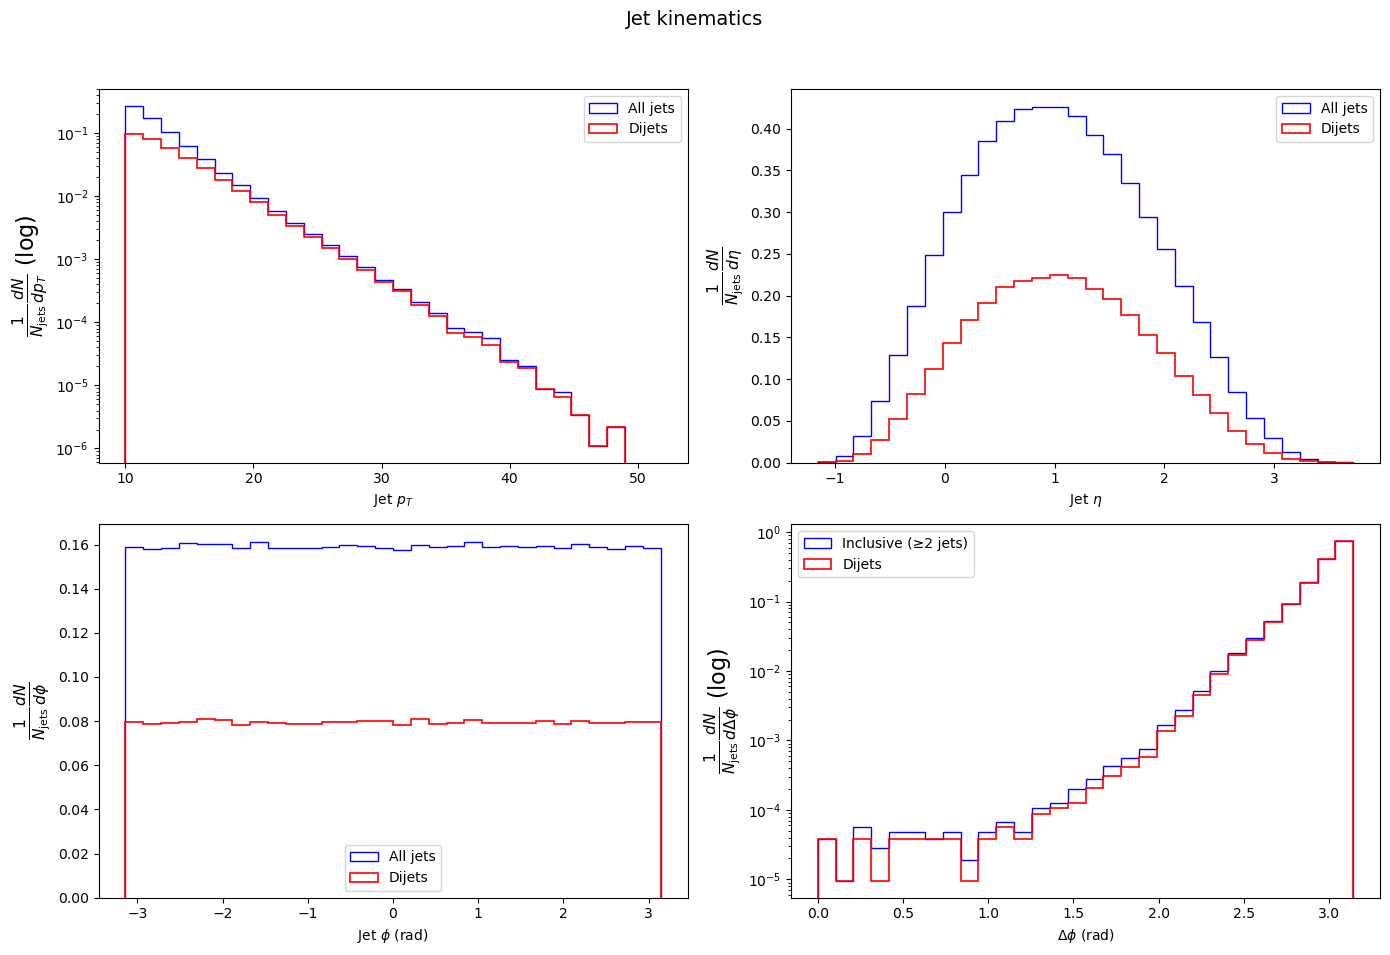

Done. Summary: {'N_events': 999681, 'N_all_jets': 645336, 'N_dijet_jets': 322210}


In [ ]:
# aggregate_and_plot_clusters.py

# ---------------- USER SETTINGS ----------------
DATA_DIR = Path("/home/ajperillo19/anaconda3/envs/EIC_ENV")   # folder with clustered_##.pkl(.gz)
PREFIX = "clustered"   # file prefix
N_FILES = 40           # number of cluster files (00 .. N_FILES-1)
EXT_CANDIDATES = [".pkl.gz", ".pkl"]   # try these in order
SAVE_PREFIX = "jet_kin_all"            # if set, will save summary figure
# ------------------------------------------------

# ---- helpers to open files ----
def open_pickle_guess(path: Path):
    """Open .pkl or .pkl.gz file (Path must exist)."""
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix == ".gz":
        with gzip.open(path, "rb") as f:
            return pickle.load(f)
    else:
        with open(path, "rb") as f:
            return pickle.load(f)

def find_cluster_file(i:int):
    """Return Path for the i-th clustered file (tries .pkl.gz then .pkl)."""
    for ext in EXT_CANDIDATES:
        p = DATA_DIR / f"{PREFIX}_{i:02d}{ext}"
        if p.exists():
            return p
    # also try bare name if EXT_CANDIDATES didn't match
    alt = DATA_DIR / f"{PREFIX}_{i:02d}"
    if alt.exists():
        return alt
    return None

def extract_named_arrays(obj):
    """
    Try to extract jpt,jeta,jphi,cpt,ceta,cphi,cmother from the loaded cluster object.
    Accepts common tuple layout or dict layout used previously.
    Returns (jpt,jeta,jphi,cpt,ceta,cphi,cmother) or raises ValueError.
    """
    if isinstance(obj, (list, tuple)):
        # typical tuple used earlier: (jpt,jeta,jphi,cpt,ceta,cphi,ccharge,cmother,pdg)
        try:
            jpt = obj[0]; jeta = obj[1]; jphi = obj[2]
            cpt = obj[3] if len(obj) > 3 else None
            ceta = obj[4] if len(obj) > 4 else None
            cphi = obj[5] if len(obj) > 5 else None
            cmother = obj[7] if len(obj) > 7 else None
            return jpt, jeta, jphi, cpt, ceta, cphi, cmother
        except Exception as e:
            raise ValueError(f"Tuple format not recognized: {e}")

    if isinstance(obj, dict):
        # try several common key names
        jpt  = obj.get("jpt")  or obj.get("jets_pt")  or obj.get("pt")    or obj.get("jet_pt")
        jeta = obj.get("jeta") or obj.get("jets_eta") or obj.get("eta")   or obj.get("jet_eta")
        jphi = obj.get("jphi") or obj.get("jets_phi") or obj.get("phi")   or obj.get("jet_phi")
        cpt  = obj.get("cpt")  or obj.get("const_pt") or obj.get("c_pt")
        ceta = obj.get("ceta") or obj.get("const_eta") or obj.get("c_eta")
        cphi = obj.get("cphi") or obj.get("const_phi") or obj.get("c_phi")
        cmother = obj.get("cmother") or obj.get("mp") or obj.get("mother")
        if jpt is None or jeta is None or jphi is None:
            raise ValueError("Could not find jpt/jeta/jphi keys in dict cluster file.")
        return jpt, jeta, jphi, cpt, ceta, cphi, cmother

    raise ValueError("Unknown cluster file format (not tuple/list/dict).")

def ensure_ak(x):
    """Return an awkward Array for x if possible (pass-through if already ak.Array)."""
    if x is None:
        return None
    if isinstance(x, ak.highlevel.Array):
        return x
    # ak.Array can accept many shapes including nested python lists
    try:
        return ak.Array(x)
    except Exception:
        # fallback: try from_iter
        return ak.from_iter(x, highlevel=True)

# ---------- the plotting function (uses per-sample weights so dijet normalizes to all jets) ----------
def _per_sample_weights(data, bins, norm_count):
    """Return per-sample weights so sum(weights in bin) = counts / norm_count."""
    if data is None or len(data) == 0 or norm_count == 0:
        return np.array([])
    widths = np.diff(bins)
    inds = np.searchsorted(bins, data, side='right') - 1
    valid = (inds >= 0) & (inds < len(widths))
    weights = np.zeros(len(data), dtype=float)
    weights[valid] = 1.0 / (float(norm_count) * widths[inds[valid]])
    return weights

def analyze_and_plot_jets_density(jpt, jeta, jphi,
                                  bins_pt=20, bins_eta=20, bins_phi=20,
                                  bins_dphi=20, pt_log_y=True,
                                  savefile_prefix=None):
    """Same analyze_and_plot_jets_density as we discussed, expects per-event awkward arrays."""
    # -- preprocess --
    jet_counts = ak.num(jpt)
    N_events = int(ak.to_numpy(ak.count(jet_counts)))
    mask_dijet = jet_counts == 2

    jpt_dijet = jpt[mask_dijet]
    jeta_dijet = jeta[mask_dijet]
    jphi_dijet = jphi[mask_dijet]

    def flatten_to_numpy(arr):
        try:
            flat = ak.flatten(arr)
            return ak.to_numpy(flat) if flat.size else np.array([])
        except Exception:
            try:
                lst = ak.to_list(arr)
                flatlist = [x for sub in lst for x in sub] if lst else []
                return np.asarray(flatlist)
            except Exception:
                return np.array([])

    flat_jpt_all   = flatten_to_numpy(jpt)
    flat_jeta_all  = flatten_to_numpy(jeta)
    flat_jphi_all  = flatten_to_numpy(jphi)

    flat_jpt_dijet  = flatten_to_numpy(jpt_dijet)
    flat_jeta_dijet = flatten_to_numpy(jeta_dijet)
    flat_jphi_dijet = flatten_to_numpy(jphi_dijet)

    N_all_jets = len(flat_jpt_all)
    N_dijet_jets = len(flat_jpt_dijet)

    print(f"Total events = {N_events}, total jets = {N_all_jets}, dijet jets = {N_dijet_jets}")

    # plotting setup
    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()

    # PT
    if N_all_jets > 0 or N_dijet_jets > 0:
        combined = np.concatenate([flat_jpt_all, flat_jpt_dijet]) if (flat_jpt_all.size or flat_jpt_dijet.size) else np.array([])
        bins_pt_edges = np.histogram_bin_edges(combined, bins=bins_pt) if combined.size else np.linspace(0,1,bins_pt+1)
        if flat_jpt_all.size:
            w_all = _per_sample_weights(flat_jpt_all, bins_pt_edges, N_all_jets)
            axes[0].hist(flat_jpt_all, bins=bins_pt_edges, weights=w_all, histtype='step', alpha=0.9999999, label='All jets', edgecolor='blue')
        if flat_jpt_dijet.size:
            w_dij = _per_sample_weights(flat_jpt_dijet, bins_pt_edges, N_all_jets)  # normalize dijet to ALL jets
            axes[0].hist(flat_jpt_dijet, bins=bins_pt_edges, weights=w_dij, histtype='step', alpha=.9999999, label='Dijets', edgecolor='red', linewidth=1.2)
        axes[0].set_xlabel('Jet $p_T$')
        axes[0].set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{dp_T}$ (log)', fontsize = 16)
        if pt_log_y:
            axes[0].set_yscale('log')
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, 'No PT data', ha='center')

    # ETA
    if flat_jeta_all.size or flat_jeta_dijet.size:
        combined = np.concatenate([flat_jeta_all, flat_jeta_dijet]) if (flat_jeta_all.size or flat_jeta_dijet.size) else np.array([])
        bins_eta_edges = np.histogram_bin_edges(combined, bins=bins_eta) if combined.size else np.linspace(-5,5,bins_eta+1)
        if flat_jeta_all.size:
            w_all = _per_sample_weights(flat_jeta_all, bins_eta_edges, N_all_jets)
            axes[1].hist(flat_jeta_all, bins=bins_eta_edges, weights=w_all, histtype='step', alpha=0.9999999, label='All jets', edgecolor='blue')
        if flat_jeta_dijet.size:
            w_dij = _per_sample_weights(flat_jeta_dijet, bins_eta_edges, N_all_jets)
            axes[1].hist(flat_jeta_dijet, bins=bins_eta_edges, weights=w_dij, histtype='step', alpha=.9999999, label='Dijets', edgecolor='red', linewidth=1.2)
        axes[1].set_xlabel('Jet $\\eta$')
        axes[1].set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\eta}$', fontsize = 16)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'No ETA data', ha='center')

    # PHI
    if flat_jphi_all.size or flat_jphi_dijet.size:
        combined = np.concatenate([flat_jphi_all, flat_jphi_dijet]) if (flat_jphi_all.size or flat_jphi_dijet.size) else np.array([])
        bins_phi_edges = np.histogram_bin_edges(combined, bins=bins_phi) if combined.size else np.linspace(-np.pi, np.pi, bins_phi+1)
        if flat_jphi_all.size:
            w_all = _per_sample_weights(flat_jphi_all, bins_phi_edges, N_all_jets)
            axes[2].hist(flat_jphi_all, bins=bins_phi_edges, weights=w_all, histtype='step', alpha=0.9999999, label='All jets', edgecolor='blue')
        if flat_jphi_dijet.size:
            w_dij = _per_sample_weights(flat_jphi_dijet, bins_phi_edges, N_all_jets)
            axes[2].hist(flat_jphi_dijet, bins=bins_phi_edges, weights=w_dij, histtype='step', alpha=.9999999, label='Dijets', edgecolor='red', linewidth=1.2)
        axes[2].set_xlabel('Jet $\\phi$ (rad)')
        axes[2].set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\phi}$', fontsize = 16)
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, 'No PHI data', ha='center')

    # Delta-phi (inclusive top-2 vs exact dijet) normalized per event (N_events)
    dphi_dijet_list = []
    dphi_incl_list = []
    jpt_list = ak.to_list(jpt)
    jphi_list = ak.to_list(jphi)
    for pt_event, phi_event in zip(jpt_list, jphi_list):
        if not phi_event:
            continue
        phi_event_arr = np.asarray(phi_event)
        pt_event_arr = np.asarray(pt_event) if pt_event else np.array([])
        if len(phi_event_arr) == 2:
            diff = abs(phi_event_arr[1] - phi_event_arr[0])
            if diff > np.pi:
                diff = 2*np.pi - diff
            dphi_dijet_list.append(diff)
        if len(phi_event_arr) >= 2 and len(pt_event_arr) >= 2:
            top2 = np.argsort(pt_event_arr)[-2:][::-1]
            phi1 = phi_event_arr[top2[0]]; phi2 = phi_event_arr[top2[1]]
            diff = abs(phi1 - phi2)
            if diff > np.pi:
                diff = 2*np.pi - diff
            dphi_incl_list.append(diff)

    dphi_dijet = np.asarray(dphi_dijet_list)
    dphi_incl = np.asarray(dphi_incl_list)
    bins_dphi_edges = np.linspace(0, np.pi, bins_dphi + 1)

    if (dphi_incl.size or dphi_dijet.size) and N_events > 0:
        if dphi_incl.size:
            w_incl = _per_sample_weights(dphi_incl, bins_dphi_edges, N_events)
            axes[3].hist(dphi_incl, bins=bins_dphi_edges, weights=w_incl, histtype='step', alpha=.9999999, label='Inclusive (≥2 jets)', edgecolor='blue')
        if dphi_dijet.size:
            w_dij = _per_sample_weights(dphi_dijet, bins_dphi_edges, N_events)
            axes[3].hist(dphi_dijet, bins=bins_dphi_edges, weights=w_dij, histtype='step', alpha=.9999999, label='Dijets', edgecolor='red', linewidth=1.2)
        axes[3].set_xlabel(r'$\Delta\phi$ (rad)')
        axes[3].set_ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\Delta\phi}$ (log)', fontsize = 16)
        axes[3].set_yscale('log')
        axes[3].legend()
    else:
        axes[3].text(0.5, 0.5, 'No Δφ data', ha='center')

    plt.suptitle("Jet kinematics", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if savefile_prefix:
        fig.savefig(f"{savefile_prefix}_summary_hist.png", dpi=200, bbox_inches='tight')
    plt.show()

    return {
        "N_events": N_events,
        "N_all_jets": N_all_jets,
        "N_dijet_jets": N_dijet_jets,
        "flat_jpt_all": flat_jpt_all,
        "flat_jeta_all": flat_jeta_all,
        "flat_jphi_all": flat_jphi_all,
        "flat_jpt_dijet": flat_jpt_dijet,
        "flat_jeta_dijet": flat_jeta_dijet,
        "flat_jphi_dijet": flat_jphi_dijet,
        "dphi_incl": dphi_incl,
        "dphi_dijet": dphi_dijet
    }

# ------------------ main loop: load cluster files and concatenate ------------------
jpt_files = []
jeta_files = []
jphi_files = []
cpt_files = []
ceta_files = []
cphi_files = []

loaded = 0
for i in range(N_FILES):
    p = find_cluster_file(i)
    if p is None:
        print(f"[skip] no file for index {i:02d}")
        continue
    print(f"[load] {p.name}")
    try:
        obj = open_pickle_guess(p)
    except Exception as e:
        print(f"  -> failed to open {p}: {e}")
        continue
    try:
        jpt, jeta, jphi, cpt, ceta, cphi, cmother = extract_named_arrays(obj)
    except ValueError as e:
        print(f"  -> couldn't parse {p.name}: {e}")
        continue

    # convert to awkward arrays (if not already)
    jpt_files.append(ensure_ak(jpt))
    jeta_files.append(ensure_ak(jeta))
    jphi_files.append(ensure_ak(jphi))
    cpt_files.append(ensure_ak(cpt) if cpt is not None else None)
    ceta_files.append(ensure_ak(ceta) if ceta is not None else None)
    cphi_files.append(ensure_ak(cphi) if cphi is not None else None)

    loaded += 1

print(f"Loaded {loaded} cluster files.")

if loaded == 0:
    raise RuntimeError("No cluster files loaded - check DATA_DIR/PREFIX/EXT_CANDIDATES")

# concatenate while tolerating None entries
def concat_safely(arrs):
    arrs_nonnull = [a for a in arrs if a is not None]
    if not arrs_nonnull:
        return None
    if len(arrs_nonnull) == 1:
        return arrs_nonnull[0]
    return ak.concatenate(arrs_nonnull)

print("Concatenating per-file arrays into global per-event arrays...")
jpt_all  = concat_safely(jpt_files)
jeta_all = concat_safely(jeta_files)
jphi_all = concat_safely(jphi_files)
cpt_all  = concat_safely([x for x in cpt_files if x is not None])
ceta_all = concat_safely([x for x in ceta_files if x is not None])
cphi_all = concat_safely([x for x in cphi_files if x is not None])

print("Calling analyze_and_plot_jets_density on aggregated arrays...")
results = analyze_and_plot_jets_density(
    jpt_all, jeta_all, jphi_all,
    bins_pt=30, bins_eta=30, bins_phi=30,
    bins_dphi=30, pt_log_y=True,
    savefile_prefix=SAVE_PREFIX
)

print("Done. Summary:", {k: results[k] for k in ("N_events","N_all_jets","N_dijet_jets")})

In [20]:
def wrap_dphi(dphi):
    """Wrap difference into [-pi, pi]."""
    return (dphi + np.pi) % (2*np.pi) - np.pi

def compute_and_plot_lambda(
    flat_jpt,
    flat_cpt,
    flat_ceta,
    flat_cphi,
    flat_jeta,
    flat_jphi,
    R: float = 0.4,
    kappa_vals: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    beta_vals:  Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    bins_lambda: int = 50,
    bins_constituent: int = 60,
    save_prefix: str = None
) -> Dict[str, Any]:
    """
    Compute lambda per jet for kappa-scan (beta fixed) and beta-scan (kappa fixed),
    plot density=True histograms and return computed arrays + bin edges.

    Parameters
    ----------
    flat_jpt : sequence of jet pT (one value per jet)
    flat_cpt : sequence of per-jet arrays/lists of constituent pT
    flat_ceta: sequence of per-jet arrays/lists of constituent eta
    flat_cphi: sequence of per-jet arrays/lists of constituent phi
    flat_jeta : sequence of jet eta (one per jet)
    flat_jphi : sequence of jet phi (one per jet)
    R : jet radius (default 0.4)
    kappa_vals, beta_vals: values to scan
    bins_lambda: number of lambda bins (default 50)
    bins_constituent: number of bins for constituent histograms (default 60)
    save_prefix: optional prefix to save figures (if provided)

    Returns
    -------
    dict containing:
      - 'lambda_kappa': dict kappa -> np.array of lambda per jet
      - 'lambda_beta' : dict beta -> np.array of lambda per jet
      - bin edges used and constituent arrays
    """
    # convert inputs to numpy-friendly forms
    flat_jpt = np.asarray(flat_jpt)
    flat_jeta = np.asarray(flat_jeta)
    flat_jphi = np.asarray(flat_jphi)

    # ensure constituent containers align with jets
    if not (len(flat_jpt) == len(flat_cpt) == len(flat_ceta) == len(flat_cphi) == len(flat_jeta) == len(flat_jphi)):
        raise ValueError("All input lists must have same length (one entry per jet).")

    n_jets = len(flat_jpt)
    if n_jets == 0:
        raise RuntimeError("No jets provided (flat_jpt empty).")

    # --- Helper to compute lambda for one jet given kappa,beta ---
    def lambda_for_jet(i, kappa, beta):
        cpt = np.asarray(flat_cpt[i])
        if cpt.size < 2:
            return None
        ceta = np.asarray(flat_ceta[i])
        cphi = np.asarray(flat_cphi[i])
        jet_pt = float(flat_jpt[i])
        if jet_pt <= 0:
            return None
        z = cpt / jet_pt
        deta = ceta - flat_jeta[i]
        dphi = wrap_dphi(cphi - flat_jphi[i])
        dR = np.sqrt(deta**2 + dphi**2)
        # sum of z^kappa * (dR/R)^beta
        return float(np.sum((z ** kappa) * ((dR / R) ** beta)))

    # ---------------------------
    # Precompute lambda ranges for shared bin edges
    # ---------------------------
    all_lambdas_kappa = []
    beta_fixed = 1.0
    for kappa in kappa_vals:
        for i in range(n_jets):
            lam = lambda_for_jet(i, kappa, beta_fixed)
            if lam is not None:
                all_lambdas_kappa.append(lam)
    if len(all_lambdas_kappa) == 0:
        raise RuntimeError("No jets with >=2 constituents found for kappa scan.")

    lam_min_kappa, lam_max_kappa = float(min(all_lambdas_kappa)), float(max(all_lambdas_kappa))
    lam_bins_kappa = np.linspace(lam_min_kappa, lam_max_kappa, bins_lambda + 1)

    # compute and plot kappa-scan (beta fixed)
    lambda_kappa = {}
    fig1, axes1 = plt.subplots(2, int(np.ceil(len(kappa_vals)/2)), figsize=(12, 8))
    axes1 = axes1.flatten()
    for idx, kappa in enumerate(kappa_vals):
        lambda_per_jet = []
        for i in range(n_jets):
            lam = lambda_for_jet(i, kappa, beta_fixed)
            if lam is None:
                continue
            lambda_per_jet.append(lam)
        lambda_per_jet = np.array(lambda_per_jet)
        lambda_kappa[kappa] = lambda_per_jet

        ax = axes1[idx]
        if lambda_per_jet.size == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
        else:
            ax.hist(lambda_per_jet, bins=lam_bins_kappa, density=True, alpha=0.9999999, histtype='step',edgecolor='blue')
            ax.set_xlabel(fr'$\lambda_{{{kappa:.2f},{beta_fixed:.2f}}}$', fontsize = 14)
            ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \lambda}$', fontsize = 14)
            ax.set_title(fr'$\kappa$={kappa:.2f}, $\beta$={beta_fixed:.2f}')
    # hide unused axes
    for j in range(len(kappa_vals), axes1.size):
        axes1[j].axis('off')
    plt.suptitle(r'Effect of varying $\kappa$', fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    if save_prefix:
        fig1.savefig(f"{save_prefix}_kappa_scan.png", dpi=200, bbox_inches='tight')
    plt.show()

    # ---------------------------
    # Constituent distributions (density=True)
    # ---------------------------
    # gather all constituents recorded while scanning (avoid duplicates by scanning once)
    all_cpt = []
    all_ceta = []
    all_cphi = []
    for i in range(n_jets):
        cpt = np.asarray(flat_cpt[i])
        if cpt.size == 0:
            continue
        all_cpt.extend(cpt.tolist())
        all_ceta.extend(np.asarray(flat_ceta[i]).tolist())
        all_cphi.extend(np.asarray(flat_cphi[i]).tolist())

    if len(all_cpt) == 0:
        raise RuntimeError("No constituents recorded (all_cpt empty).")

    all_cpt_arr = np.asarray(all_cpt)
    all_ceta_arr = np.asarray(all_ceta)
    all_cphi_arr = np.asarray(all_cphi)

    fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    ax1.hist(all_cpt_arr, bins=bins_constituent, density=True, histtype='step', alpha=0.9999999, edgecolor='blue')
    ax1.set_yscale('log')
    ax1.set_ylabel(r'$\frac{1}{N_{cons}} \frac{dN}{dp_t}$', fontsize = 14)
    ax1.set_xlabel('$p_T$ (GeV/c)'); ax1.set_title('constituent $p_T$')

    ax2.hist(all_ceta_arr, bins=bins_constituent, density=True, histtype='step', alpha=0.9999999,  edgecolor='blue')
    ax2.set_ylabel(r'$\frac{1}{N_{cons}} \frac{dN}{d \eta}$', fontsize = 14)
    ax2.set_xlabel('$\\eta$'); ax2.set_title('constituent $\\eta$')

    phi_bins = np.linspace(-np.pi, np.pi, bins_constituent+1)
    ax3.hist(all_cphi_arr, bins=phi_bins, density=True, alpha=0.9999999, histtype='step', edgecolor='blue')
    ax3.set_ylabel(r'$\frac{1}{N_{cons}} \frac{dN}{d \phi}$', fontsize = 14)
    ax3.set_xlabel('$\\phi$ (rad)'); ax3.set_title('constituent $\phi$')

    plt.suptitle('Constituent probability densities', fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.95])
    if save_prefix:
        fig2.savefig(f"{save_prefix}_constituents.png", dpi=200, bbox_inches='tight')
    plt.show()

    # ---------------------------
    # 2) Beta-scan (kappa fixed)
    # ---------------------------
    kappa_fixed = 1.0
    all_lambdas_beta = []
    for beta in beta_vals:
        for i in range(n_jets):
            lam = lambda_for_jet(i, kappa_fixed, beta)
            if lam is not None:
                all_lambdas_beta.append(lam)
    if len(all_lambdas_beta) == 0:
        raise RuntimeError("No jets with >= 2 constituents found for beta scan.")
    lam_min_beta, lam_max_beta = float(min(all_lambdas_beta)), float(max(all_lambdas_beta))
    lam_bins_beta = np.linspace(lam_min_beta, lam_max_beta, bins_lambda + 1)

    lambda_beta = {}
    fig3, axes3 = plt.subplots(2, int(np.ceil(len(beta_vals)/2)), figsize=(12, 8))
    axes3 = axes3.flatten()
    for idx, beta in enumerate(beta_vals):
        lambda_per_jet = []
        for i in range(n_jets):
            lam = lambda_for_jet(i, kappa_fixed, beta)
            if lam is None:
                continue
            lambda_per_jet.append(lam)
        lambda_per_jet = np.array(lambda_per_jet)
        lambda_beta[beta] = lambda_per_jet

        ax = axes3[idx]
        if lambda_per_jet.size == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
        else:
            ax.hist(lambda_per_jet, bins=lam_bins_beta, density=True, alpha=0.9999999, histtype='step',edgecolor='blue')
            ax.set_xlabel(fr'$\lambda_{{{kappa_fixed:.2f},{beta:.2f}}}$', fontsize = 14)
            ax.set_ylabel(r'$\frac{1}{N_{jets}} \frac{dN}{d \lambda}$', fontsize = 14)
            ax.set_title(fr'$\kappa$={kappa_fixed:.2f}, $\beta$={beta:.2f}')
    for j in range(len(beta_vals), axes3.size):
        axes3[j].axis('off')
    plt.suptitle(r'Effect of varying $\beta$', fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.96])
    if save_prefix:
        fig3.savefig(f"{save_prefix}_beta_scan.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Return computed quantities and bin edges for later inspection
    return {
        "lambda_kappa": lambda_kappa,
        "lam_bins_kappa": lam_bins_kappa,
        "lambda_beta": lambda_beta,
        "lam_bins_beta": lam_bins_beta,
        "constituents": {
            "cpt": all_cpt_arr,
            "ceta": all_ceta_arr,
            "cphi": all_cphi_arr
        }
    }

<>:156: SyntaxWarning: invalid escape sequence '\p'
<>:156: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_246427/2912211355.py:156: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_xlabel('$\\phi$ (rad)'); ax3.set_title('constituent $\phi$')


Loaded clustered_00.pkl
Loaded clustered_01.pkl
Loaded clustered_02.pkl
Loaded clustered_03.pkl
Loaded clustered_04.pkl
Loaded clustered_05.pkl
Loaded clustered_06.pkl
Loaded clustered_07.pkl
Loaded clustered_08.pkl
Loaded clustered_09.pkl
Loaded clustered_10.pkl
Loaded clustered_11.pkl
Loaded clustered_12.pkl
Loaded clustered_13.pkl
Loaded clustered_14.pkl
Loaded clustered_15.pkl
Loaded clustered_16.pkl
Loaded clustered_17.pkl
Loaded clustered_18.pkl
Loaded clustered_19.pkl
Loaded clustered_20.pkl
Loaded clustered_21.pkl
Loaded clustered_22.pkl
Loaded clustered_23.pkl
Loaded clustered_24.pkl
Loaded clustered_25.pkl
Loaded clustered_26.pkl
Loaded clustered_27.pkl
Loaded clustered_28.pkl
Loaded clustered_29.pkl
Loaded clustered_30.pkl
Loaded clustered_31.pkl
Loaded clustered_32.pkl
Loaded clustered_33.pkl
Loaded clustered_34.pkl
Loaded clustered_35.pkl
Loaded clustered_36.pkl
Loaded clustered_37.pkl
Loaded clustered_38.pkl
Loaded clustered_39.pkl
Loaded 40 cluster files.
Prepared per-je

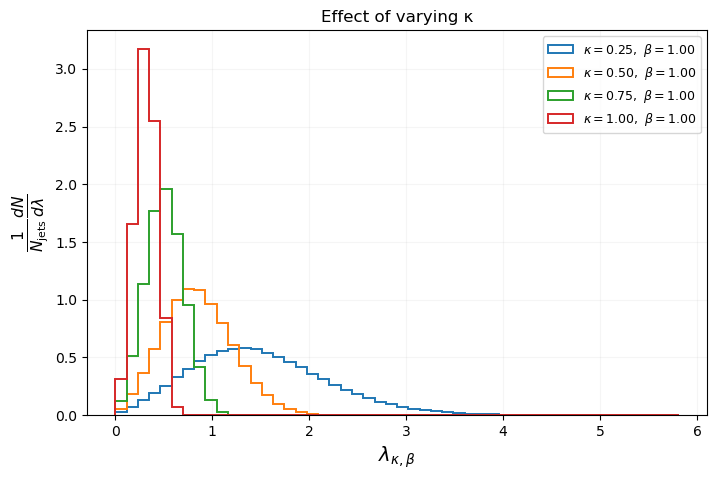

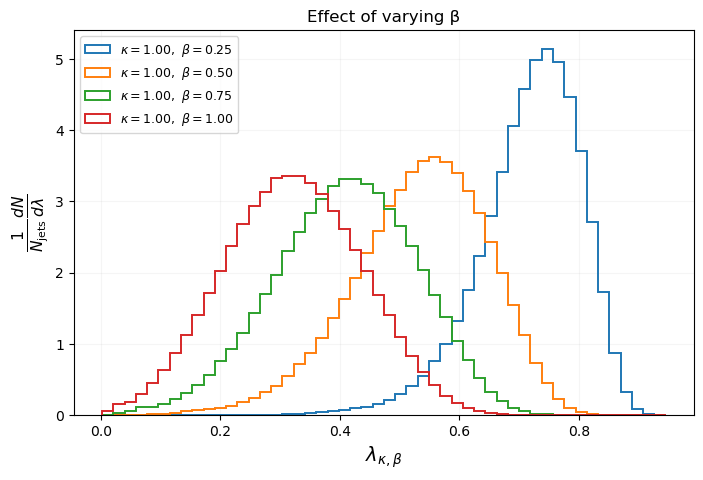

Done. Keys returned: ['kappa_overlay', 'beta_overlay']


In [21]:
# ------------------ User settings ------------------
DATA_DIR = Path("/home/ajperillo19/anaconda3/envs/EIC_ENV")
PREFIX = "clustered"          # gives clustered_00.pkl.gz or clustered_00.pkl
N_FILES = 40                  # 00 .. 39
EXT_CANDIDATES = [".pkl.gz", ".pkl"]
SAVE_PREFIX = "lambda_scan_all"
kappa_vals = (0.25, 0.5, 0.75, 1.0)
beta_vals  = (0.25, 0.5, 0.75, 1.0)
bins_lambda = 50
# ---------------------------------------------------

def open_pickle_guess(path: Path):
    """Open .pkl or .pkl.gz and return loaded object (or raise)."""
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix == ".gz":
        with gzip.open(path, "rb") as f:
            return pickle.load(f)
    else:
        with open(path, "rb") as f:
            return pickle.load(f)

def find_cluster_file(i:int):
    """Return Path for the i-th clustered file (tries .pkl.gz then .pkl)."""
    for ext in EXT_CANDIDATES:
        p = DATA_DIR / f"{PREFIX}_{i:02d}{ext}"
        if p.exists():
            return p
    # fallback exact name
    alt = DATA_DIR / f"{PREFIX}_{i:02d}"
    if alt.exists():
        return alt
    return None

def extract_from_loaded(obj):
    """Try to extract (jpt, jeta, jphi, cpt, ceta, cphi) from loaded object.
       Accepts tuple/list (positional) or dict (keyed) storage.
    """
    if isinstance(obj, (tuple, list)):
        # expected ordering used earlier: (jpt, jeta, jphi, cpt, ceta, cphi, ...)
        if len(obj) >= 6:
            return obj[0], obj[1], obj[2], obj[3], obj[4], obj[5]
        else:
            raise ValueError("Tuple/list cluster file has <6 entries.")
    if isinstance(obj, dict):
        # try common keys
        jpt = obj.get("jpt") or obj.get("jets_pt") or obj.get("pt") or obj.get("jet_pt")
        jeta= obj.get("jeta") or obj.get("jets_eta") or obj.get("eta") or obj.get("jet_eta")
        jphi= obj.get("jphi") or obj.get("jets_phi") or obj.get("phi") or obj.get("jet_phi")
        cpt = obj.get("cpt")  or obj.get("const_pt") or obj.get("c_pt")
        ceta= obj.get("ceta") or obj.get("const_eta") or obj.get("c_eta")
        cphi= obj.get("cphi") or obj.get("const_phi") or obj.get("c_phi")
        if jpt is None or jeta is None or jphi is None:
            raise ValueError("Could not find jpt/jeta/jphi in dict cluster file.")
        return jpt, jeta, jphi, cpt, ceta, cphi
    raise ValueError("Unknown cluster file format (not tuple/list/dict).")

def ensure_ak(x):
    """Turn x into an awkward Array (or return None if x is None)."""
    if x is None:
        return None
    if isinstance(x, ak.highlevel.Array):
        return x
    try:
        return ak.Array(x)
    except Exception:
        # best-effort wrap
        return ak.from_iter(x, highlevel=True)

# Paste/adapt compute_and_plot_lambda_overlay from earlier (keeps function local)
def wrap_dphi(dphi):
    return (dphi + np.pi) % (2*np.pi) - np.pi

def compute_and_plot_lambda_overlay(
    flat_jpt,
    flat_cpt_list,
    flat_ceta_list,
    flat_cphi_list,
    flat_jeta,
    flat_jphi,
    R: float = 0.4,
    kappa_vals: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    beta_vals:  Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    bins_lambda: int = 50,
    density: bool = True,
    save_prefix: str | None = None
) -> Dict[str, Any]:
    flat_jpt = np.asarray(flat_jpt)
    flat_jeta = np.asarray(flat_jeta)
    flat_jphi = np.asarray(flat_jphi)
    n_jets = len(flat_jpt)
    if not (len(flat_jeta) == len(flat_jphi) == n_jets):
        raise ValueError("flat_jpt/eta/phi length mismatch.")
    if not (len(flat_cpt_list) == len(flat_ceta_list) == len(flat_cphi_list) == n_jets):
        raise ValueError("constituent lists length mismatch.")

    def lambda_for_jet(i, kappa, beta):
        cpt = np.asarray(flat_cpt_list[i])
        if cpt.size < 2:
            return None
        ceta = np.asarray(flat_ceta_list[i])
        cphi = np.asarray(flat_cphi_list[i])
        jet_pt = float(flat_jpt[i])
        if jet_pt <= 0:
            return None
        z = cpt / jet_pt
        deta = ceta - flat_jeta[i]
        dphi = wrap_dphi(cphi - flat_jphi[i])
        dR = np.sqrt(deta**2 + dphi**2)
        return float(np.sum((z ** kappa) * ((dR / R) ** beta)))

    def compute_for_paramlist(param_list, which='kappa', fixed_val=1.0):
        results = {}
        for val in param_list:
            lambdas = []
            if which == 'kappa':
                kappa, beta = float(val), float(fixed_val)
            else:
                kappa, beta = float(fixed_val), float(val)
            for i in range(n_jets):
                lam = lambda_for_jet(i, kappa, beta)
                if lam is not None:
                    lambdas.append(lam)
            arr = np.array(lambdas)
            if arr.size:
                arr = arr[arr != 0]
            results[val] = arr
        return results

    # Kappa overlay (beta fixed)
    beta_fixed = 1.0
    kappa_results = compute_for_paramlist(kappa_vals, which='kappa', fixed_val=beta_fixed)
    combined_kappa_vals = np.concatenate([arr for arr in kappa_results.values() if arr.size]) if any(arr.size for arr in kappa_results.values()) else np.array([])
    bins_kappa = np.histogram_bin_edges(combined_kappa_vals, bins=bins_lambda) if combined_kappa_vals.size else np.linspace(0,1,bins_lambda+1)

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors = prop_cycle * ((len(kappa_vals) // len(prop_cycle)) + 1)

    plt.figure(figsize=(8,5))
    for idx, kappa in enumerate(kappa_vals):
        arr = kappa_results[kappa]
        if arr.size:
            plt.hist(arr, bins=bins_kappa, density=density, histtype='step', linewidth=1.4,
                     label=fr'$\kappa={kappa:.2f},\ \beta={beta_fixed:.2f}$', color=colors[idx])
        else:
            plt.plot([], [], color=colors[idx], label=fr'$\kappa={kappa:.2f},\ \beta={beta_fixed:.2f}$')
    plt.xlabel(r'$\lambda_{\kappa,\beta}$', fontsize=14)
    plt.ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$' if density else 'Counts', fontsize=16)
    plt.title(f'Effect of varying κ')
    plt.legend(fontsize=9, loc='best')
    plt.grid(alpha=0.12)
    if save_prefix:
        plt.savefig(f"{save_prefix}_kappa_overlay.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Beta overlay (kappa fixed)
    kappa_fixed = 1.0
    beta_results = compute_for_paramlist(beta_vals, which='beta', fixed_val=kappa_fixed)
    combined_beta_vals = np.concatenate([arr for arr in beta_results.values() if arr.size]) if any(arr.size for arr in beta_results.values()) else np.array([])
    bins_beta = np.histogram_bin_edges(combined_beta_vals, bins=bins_lambda) if combined_beta_vals.size else np.linspace(0,1,bins_lambda+1)
    colors2 = prop_cycle * ((len(beta_vals) // len(prop_cycle)) + 1)

    plt.figure(figsize=(8,5))
    for idx, beta in enumerate(beta_vals):
        arr = beta_results[beta]
        if arr.size:
            plt.hist(arr, bins=bins_beta, density=density, histtype='step', linewidth=1.4,
                     label=fr'$\kappa={kappa_fixed:.2f},\ \beta={beta:.2f}$', color=colors2[idx])
        else:
            plt.plot([], [], color=colors2[idx], label=fr'$\kappa={kappa_fixed:.2f},\ \beta={beta:.2f}$')
    plt.xlabel(r'$\lambda_{\kappa,\beta}$', fontsize=14)
    plt.ylabel(r'$\frac{1}{N_{\rm jets}}\frac{dN}{d\lambda}$' if density else 'Counts', fontsize=16)
    plt.title(f'Effect of varying β')
    plt.legend(fontsize=9, loc='best')
    plt.grid(alpha=0.12)
    if save_prefix:
        plt.savefig(f"{save_prefix}_beta_overlay.png", dpi=200, bbox_inches='tight')
    plt.show()

    return {
        "kappa_overlay": {"results": kappa_results, "bins": bins_kappa, "beta_fixed": beta_fixed},
        "beta_overlay":  {"results": beta_results,  "bins": bins_beta,  "kappa_fixed": kappa_fixed}
    }

# ------------------ Load & concat cluster files ------------------
jpt_files = []
jeta_files = []
jphi_files = []
cpt_files = []
ceta_files = []
cphi_files = []

loaded = 0
for i in range(N_FILES):
    p = find_cluster_file(i)
    if p is None:
        print(f"Missing file for index {i:02d} (tried {EXT_CANDIDATES}). Skipping.")
        continue
    try:
        obj = open_pickle_guess(p)
    except Exception as e:
        print(f"Failed to load {p.name}: {e}. Skipping.")
        continue

    try:
        jpt, jeta, jphi, cpt, ceta, cphi = extract_from_loaded(obj)
    except Exception as e:
        print(f"Couldn't parse {p.name}: {e}. Skipping.")
        continue

    jpt_files.append(ensure_ak(jpt))
    jeta_files.append(ensure_ak(jeta))
    jphi_files.append(ensure_ak(jphi))
    # constituents might be None in some formats -> keep placeholders to preserve indexing if you like
    cpt_files.append(ensure_ak(cpt) if cpt is not None else None)
    ceta_files.append(ensure_ak(ceta) if ceta is not None else None)
    cphi_files.append(ensure_ak(cphi) if cphi is not None else None)

    loaded += 1
    print(f"Loaded {p.name}")

print(f"Loaded {loaded} cluster files.")

if loaded == 0:
    raise RuntimeError("No cluster files loaded. Check DATA_DIR and PREFIX.")

def concat_safely(arr_list):
    arrs = [a for a in arr_list if a is not None]
    if not arrs:
        return None
    if len(arrs) == 1:
        return arrs[0]
    return ak.concatenate(arrs)

flat_jpt_all  = concat_safely(jpt_files)
flat_jeta_all = concat_safely(jeta_files)
flat_jphi_all = concat_safely(jphi_files)

# Concatenate only those files that included constituents (skip None)
cpt_nonnull = [x for x in cpt_files if x is not None]
ceta_nonnull = [x for x in ceta_files if x is not None]
cphi_nonnull = [x for x in cphi_files if x is not None]

if not (cpt_nonnull and ceta_nonnull and cphi_nonnull):
    raise RuntimeError("Constituent arrays missing from all cluster files; cannot compute angularities.")

flat_cpt_all  = concat_safely(cpt_nonnull)
flat_ceta_all = concat_safely(ceta_nonnull)
flat_cphi_all = concat_safely(cphi_nonnull)


# flatten jets -> produce per-jet scalars
flat_jpt_np  = ak.to_numpy(ak.flatten(flat_jpt_all))
flat_jeta_np = ak.to_numpy(ak.flatten(flat_jeta_all))
flat_jphi_np = ak.to_numpy(ak.flatten(flat_jphi_all))

# flatten constituents so we have one element per jet, each element is an array of constituents
perjet_cpt = ak.flatten(flat_cpt_all)   # jagged: jets -> constituents
perjet_ceta = ak.flatten(flat_ceta_all)
perjet_cphi = ak.flatten(flat_cphi_all)

flat_cpt_list  = ak.to_list(perjet_cpt)
flat_ceta_list = ak.to_list(perjet_ceta)
flat_cphi_list = ak.to_list(perjet_cphi)

print("Prepared per-jet arrays/lists. Calling compute_and_plot_lambda_overlay (may take time).")

results = compute_and_plot_lambda_overlay(
    flat_jpt_np,
    flat_cpt_list,
    flat_ceta_list,
    flat_cphi_list,
    flat_jeta_np,
    flat_jphi_np,
    R=0.4,
    kappa_vals=kappa_vals,
    beta_vals=beta_vals,
    bins_lambda=bins_lambda,
    density=True,
    save_prefix=SAVE_PREFIX
)

print("Done. Keys returned:", list(results.keys()))